FOEN Qmax events for ICH1 & 2 above 400 m3/s by lead time

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

path = r"..\\outputs\\OFEV_probabilistic\\station2170_ensemble_wide.csv"
start = pd.Timestamp("2024-05-28")
end = pd.Timestamp("2025-12-31 23:59:59")
threshold = 400

# Keep only these models for analysis/correction
keep_models = ["ICH1", "ICH2"]

raw = pd.read_csv(path, parse_dates=["valid_time"])
q_cols = [c for c in raw.columns if c.startswith("Q_e")]
raw = raw.loc[raw["valid_time"].between(start, end)].copy()
raw = raw.loc[raw["model"].isin(keep_models)].copy()
raw["Q_max"] = raw[q_cols].max(axis=1)

lead_times = sorted(raw["lead_time_h"].dropna().unique())
events_by_lt = {}
qmax_by_lt = {}
coverage_by_lt = {}

for lt in lead_times:
    frame = raw.loc[raw["lead_time_h"] == lt].copy()
    qmax = (
        frame.groupby(["valid_time", "model"])["Q_max"]
        .max()
        .unstack("model")
        .sort_index()
    )
    qmax_by_lt[lt] = qmax

    # Coverage diagnostics: how much each model contributes at this lead time
    model_stats = (
        frame.groupby("model")["valid_time"]
        .agg(n_rows="size", n_times="nunique", first_time="min", last_time="max")
        .sort_values(["n_times", "n_rows"], ascending=False)
    )
    total_times = len(qmax.index)
    if total_times > 0:
        model_stats["pct_times"] = (model_stats["n_times"] / total_times * 100.0).round(1)
    else:
        model_stats["pct_times"] = 0.0
    coverage_by_lt[lt] = model_stats

    overall = qmax.max(axis=1)
    above = overall > threshold
    starts = overall.index[above & ~above.shift(fill_value=False)]
    ends = overall.index[above & ~above.shift(-1, fill_value=False)]

    events = pd.DataFrame({"start": starts, "end": ends}).reset_index(drop=True)
    if not events.empty:
        events["peak_Qmax"] = [overall.loc[s:e].max() for s, e in zip(events["start"], events["end"])]
    events_by_lt[lt] = events

for lt in lead_times:
    display(Markdown(f"Lead time {int(lt)} h"))
    display(Markdown("Model coverage in selected window"))
    display(coverage_by_lt[lt])
    display(Markdown("Events (overall max across models > threshold)"))
    display(events_by_lt[lt])

    for m in keep_models:
        if m in coverage_by_lt[lt].index:
            row = coverage_by_lt[lt].loc[m]
            display(Markdown(
                f"{m}: n_times={int(row['n_times'])} ({row['pct_times']}% of timestamps), "
                f"range {row['first_time']} → {row['last_time']}"
            ))
        else:
            display(Markdown(f"{m}: not present at this lead time in window"))

Lead time 6 h

Model coverage in selected window

,n_rows,n_times,first_time,last_time,pct_times
model,,,,,
ICH2,585,583,2024-05-28 12:00:00,2025-12-30 12:00:00,50.1
ICH1,584,582,2024-05-28 11:00:00,2025-12-30 11:00:00,50.0


Events (overall max across models > threshold)

,start,end,peak_Qmax
0,2024-06-15 12:00:00,2024-06-15 12:00:00,411.0
1,2024-07-12 12:00:00,2024-07-12 12:00:00,427.7
2,2025-01-28 11:00:00,2025-01-28 11:00:00,413.0
3,2025-06-07 11:00:00,2025-06-07 12:00:00,601.2
4,2025-10-23 12:00:00,2025-10-23 12:00:00,422.4
5,2025-11-02 11:00:00,2025-11-02 12:00:00,574.8


...

,n_rows,n_times,first_time,last_time,pct_times
model,,,,,
ICH2,584,582,2024-05-30 06:00:00,2025-12-31 06:00:00,100.0


Events (overall max across models > threshold)

,start,end,peak_Qmax
0,2024-06-10 06:00:00,2024-06-10 06:00:00,593.2
1,2024-06-16 06:00:00,2024-06-16 06:00:00,535.5
2,2024-06-30 06:00:00,2024-06-30 06:00:00,631.8
3,2024-07-07 06:00:00,2024-07-07 06:00:00,596.0
4,2024-07-13 06:00:00,2024-07-13 06:00:00,673.4
5,2024-07-16 06:00:00,2024-07-16 06:00:00,586.9
6,2024-09-27 06:00:00,2024-09-27 06:00:00,514.1
7,2024-10-02 06:00:00,2024-10-02 06:00:00,547.4
8,2025-06-05 06:00:00,2025-06-05 06:00:00,493.7
9,2025-10-30 06:00:00,2025-10-30 06:00:00,445.4


ICH1: not present at this lead time in window

ICH2: n_times=582 (100.0% of timestamps), range 2024-05-30 06:00:00 → 2025-12-31 06:00:00

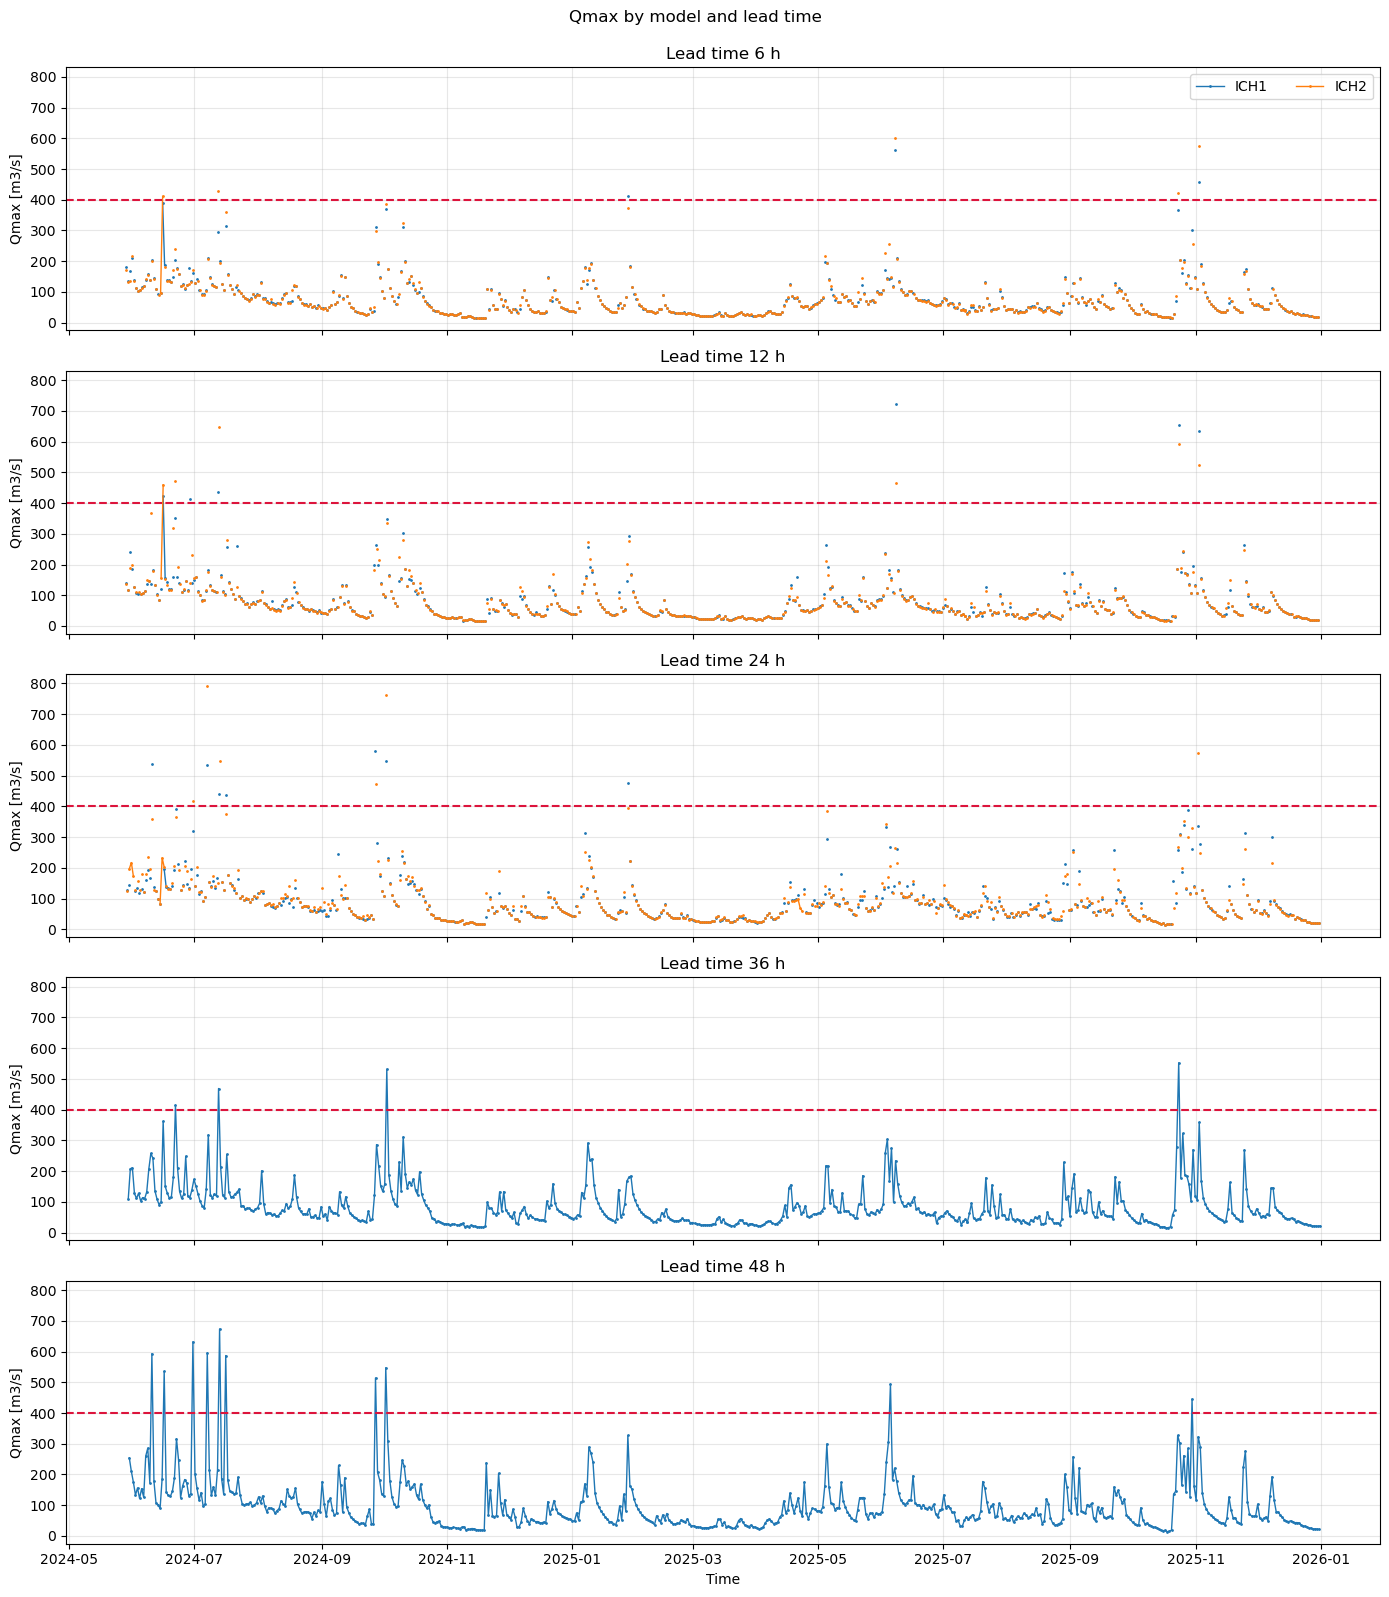

In [2]:
fig, axes = plt.subplots(len(lead_times), 1, figsize=(14, 3.2 * len(lead_times)), sharex=True, sharey=True)

if len(lead_times) == 1:
    axes = [axes]

for ax, lt in zip(axes, lead_times):
    qmax = qmax_by_lt[lt]
    for model in qmax.columns:
        ax.plot(qmax.index, qmax[model], lw=1.0, marker='.', ms=2.0, label=model)
    ax.axhline(threshold, color="crimson", ls="--", lw=1.5)
    ax.set_title(f"Lead time {int(lt)} h")
    ax.set_ylabel("Qmax [m3/s]")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
axes[0].legend(ncol=2, loc="upper right")
fig.suptitle("Qmax by model and lead time", y=0.995)
plt.tight_layout()
plt.show()

observations time series over the analysis window

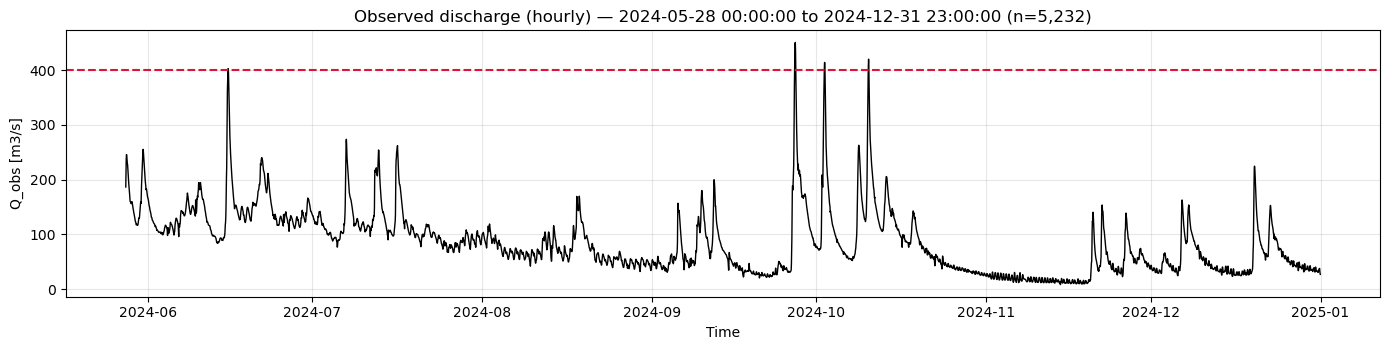

In [ ]:
# Plot observed discharge time series over the analysis window
import math
from pathlib import Path
import numpy as np

# Observations (10-min means) for station 2170
DATA_DIR = Path("..") / "data" / "Data Fornisseurs"
obs_path = DATA_DIR / "ARVE/2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv"
obs_end = pd.Timestamp("2024-12-31 23:59:59")
end_rank = min(end, obs_end)

# The obs file has an 8-line metadata block, then a ';'-separated table in Windows-1252 encoding
obs = pd.read_csv(
    obs_path,
    sep=";",
    encoding="cp1252",
    skiprows=8,
    usecols=["Zeitstempel", "Wert"],
    parse_dates=["Zeitstempel"],
)
obs = obs.rename(columns={"Zeitstempel": "valid_time", "Wert": "Q_obs"})
obs["Q_obs"] = pd.to_numeric(obs["Q_obs"], errors="coerce")
obs = obs.dropna(subset=["Q_obs"])
obs = obs.loc[obs["valid_time"].between(start, end_rank)].copy()

# Forecasts are hourly timestamps; keep the obs values at exact HH:00 timestamps
obs = obs.loc[obs["valid_time"].dt.minute.eq(0) & obs["valid_time"].dt.second.eq(0)]
obs_hr = obs.set_index("valid_time")["Q_obs"].sort_index()

fig, ax = plt.subplots(1, 1, figsize=(14, 3.6))
ax.plot(obs_hr.index, obs_hr.values, lw=1.0, color="black")
ax.axhline(threshold, color="crimson", ls="--", lw=1.5)
ax.set_title(f"Observed discharge (hourly) — {obs_hr.index.min()} to {obs_hr.index.max()} (n={len(obs_hr):,})")
ax.set_ylabel("Q_obs [m3/s]")
ax.set_xlabel("Time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Rank histograms vs observations (until 2024-12-31)

Obs loaded: n=5,232 hourly points from 2024-05-28 00:00:00 to 2024-12-31 23:00:00

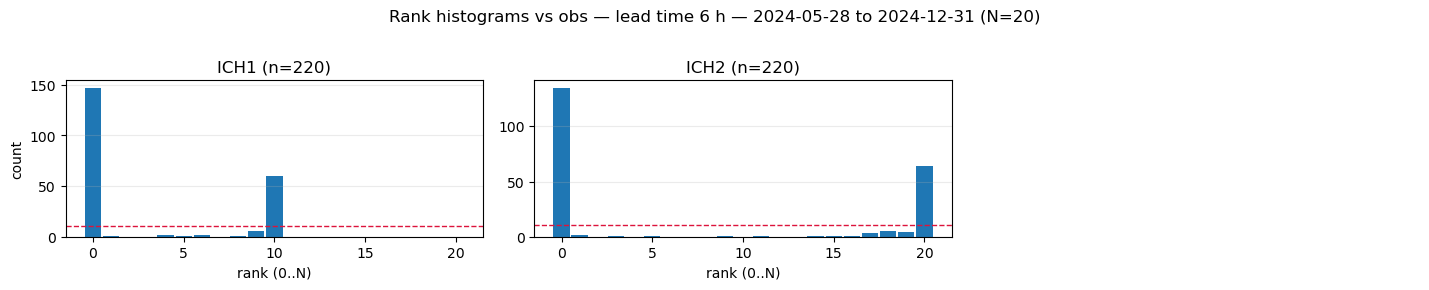

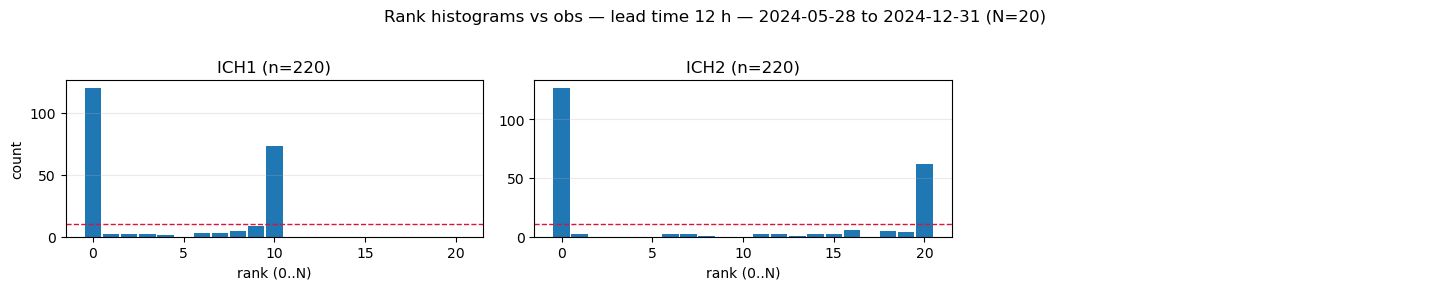

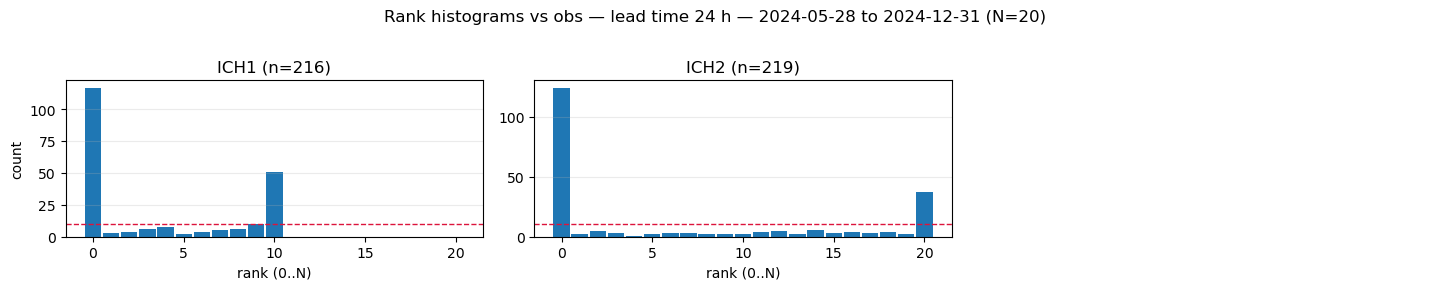

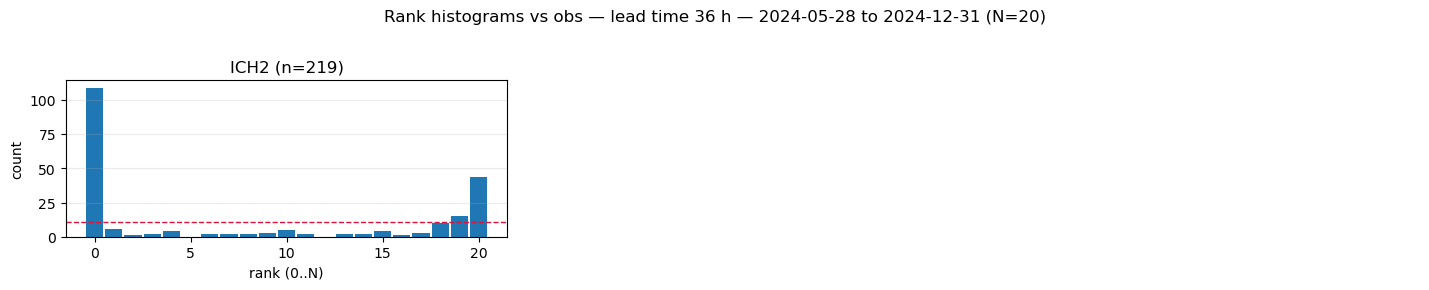

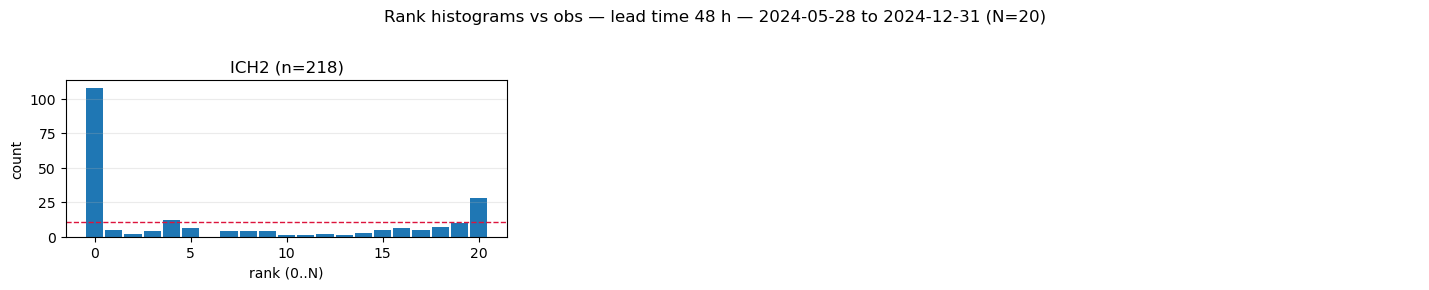

In [ ]:
display(Markdown(f"Obs loaded: n={len(obs_hr):,} hourly points from {obs_hr.index.min()} to {obs_hr.index.max()}"))

if not q_cols:
    raise ValueError("No ensemble member columns found (expected columns starting with 'Q_e').")

N = len(q_cols)
rng = np.random.default_rng(42)

def rank_of_obs(ens: np.ndarray, obs_value: float) -> int:
    """Return rank in {0..N} where N=len(ens). Tie-handled randomly for reproducibility."""
    # ens length should be N; allow NaNs defensively
    ens = ens.astype(float, copy=False)
    valid = ~np.isnan(ens)
    ens = ens[valid]
    if ens.size == 0 or np.isnan(obs_value):
        return None
    less = int(np.sum(ens < obs_value))
    eq = int(np.sum(ens == obs_value))
    if eq > 0:
        # obs falls within a tie block; choose uniformly among possible ranks
        return int(less + rng.integers(0, eq + 1))
    return less

rank_hists = {}   # (lt, model) -> counts array length N+1
rank_sizes = {}   # (lt, model) -> number of cases used

for lt in lead_times:
    models = sorted(raw.loc[raw["lead_time_h"] == lt, "model"].dropna().unique())
    for model_name in models:
        frame = raw.loc[(raw["lead_time_h"] == lt) & (raw["model"] == model_name), ["valid_time"] + q_cols].copy()
        frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
        if frame.empty:
            continue
        ranks = []
        for _, row in frame.iterrows():
            r = rank_of_obs(row[q_cols].to_numpy(), float(row["Q_obs"]))
            if r is not None:
                ranks.append(r)
        if not ranks:
            continue
        ranks = np.asarray(ranks, dtype=int)
        rank_hists[(lt, model_name)] = np.bincount(ranks, minlength=N + 1)
        rank_sizes[(lt, model_name)] = int(ranks.size)

# Plot: one figure per lead time, with one subplot per model
for lt in lead_times:
    models = sorted(raw.loc[raw["lead_time_h"] == lt, "model"].dropna().unique())
    models = [m for m in models if (lt, m) in rank_hists]
    if not models:
        display(Markdown(f"### Lead time {int(lt)} h — no obs-aligned cases"))
        continue

    ncols = 3
    nrows = math.ceil(len(models) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 2.8 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    x = np.arange(N + 1)
    for ax, m in zip(axes, models):
        counts = rank_hists[(lt, m)]
        n_cases = rank_sizes[(lt, m)]
        ax.bar(x, counts, width=0.9)
        ax.axhline(n_cases / (N + 1), color="crimson", ls="--", lw=1.0)
        ax.set_title(f"{m} (n={n_cases})")
        ax.grid(True, axis="y", alpha=0.25)

    for ax in axes[len(models):]:
        ax.axis("off")

    axes[0].set_ylabel("count")
    for ax in axes[max(0, len(models) - ncols):len(models)]:
        ax.set_xlabel("rank (0..N)")

    fig.suptitle(
        f"Rank histograms vs obs — lead time {int(lt)} h — {start.date()} to {end_rank.date()} (N={N})",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

# Global bias + spread inflation (one per model, all lead times)
We fit **one correction per model** (ICH1, ICH2) using all lead times together over the obs-available period.
Correction applied to ensemble members:
- Bias shift (additive): $\mu' = \mu + b$ where $b = \mathbb{E}[Q_{obs} - \mu]$
- Spread inflation around the (shifted) mean: $x' = \mu' + f\,(x-\mu)$
We choose $f$ by minimizing the mean CRPS of the corrected ensemble vs obs over the calibration period.

**Limitations**
- Mixing all lead times means the fitted $b$ and $f$ are an *average* across lead times; if dispersion/bias varies with lead time, this will not be optimal for each lead time.
- A strong peak at rank 0/20 can reflect **bias** (mis-centered ensemble), not only underdispersion; inflation alone cannot fix bias, so we apply both a shift and inflation.
- Using only one station/period can overfit to that season/hydrologic regime; validate on a different time slice if possible.

Fitted correction per model:

,bias,f,n_cases,crps_before,crps_after
ICH1,-2.342370,1.22,656.0,10.150509,9.697753
ICH2,-2.502142,1.40,1096.0,12.403185,11.817416


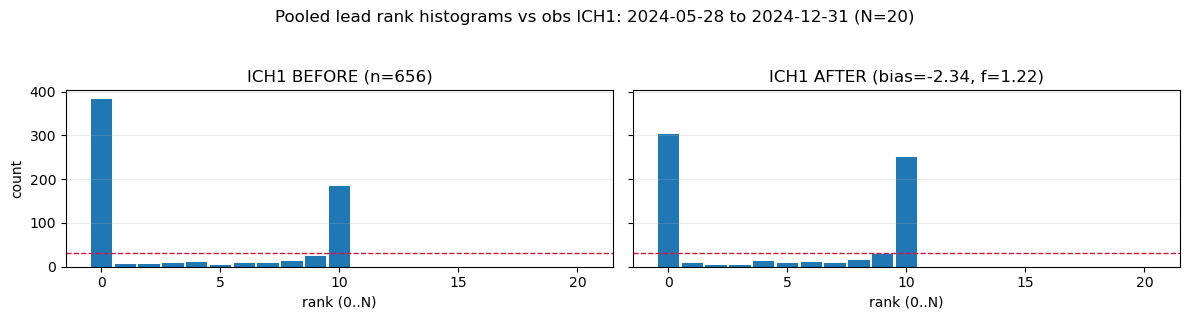

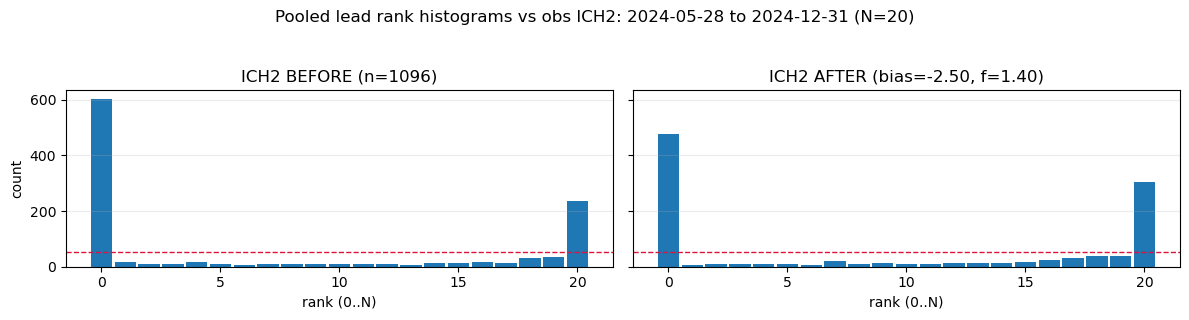

In [15]:
import numpy as np

# Calibration period is limited by obs availability
cal_end = end_rank  
cal_start = start
N = len(q_cols)

def crps_ensemble(x: np.ndarray, y: float) -> float:
    """CRPS for a finite ensemble sample x (shape [N])."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0 or np.isnan(y):
        return np.nan
    x_sorted = np.sort(x)
    n = x_sorted.size
    term1 = np.mean(np.abs(x_sorted - y))
    # pairwise absolute differences for sorted sample
    i = np.arange(1, n + 1, dtype=float)  # 1..n
    pair_sum = np.sum((2 * i - n - 1) * x_sorted)
    term2 = pair_sum / (n * n)
    return float(term1 - term2)

def apply_bias_inflation(ens: np.ndarray, bias: float, f: float) -> np.ndarray:
    ens = np.asarray(ens, dtype=float)
    mu = np.nanmean(ens)
    return (mu + bias) + f * (ens - mu)

# Build calibration cases and fit per model
calibration = {}  # model -> dict(bias, f, n_cases, crps_before, crps_after)
f_grid = np.linspace(0.8, 2.0, 61)

for model_name in keep_models:
    frame = raw.loc[raw["model"] == model_name, ["valid_time"] + q_cols].copy()
    frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
    frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")

    ens_mean = frame[q_cols].mean(axis=1)
    bias = float((frame["Q_obs"] - ens_mean).mean())
    y = frame["Q_obs"].to_numpy(dtype=float)
    ens = frame[q_cols].to_numpy(dtype=float)

    # CRPS before correction
    crps0 = np.nanmean([crps_ensemble(ens[i], y[i]) for i in range(len(frame))])

    best = (np.inf, None)  # (crps, f)
    for f in f_grid:
        crps_f = np.nanmean([crps_ensemble(apply_bias_inflation(ens[i], bias, f), y[i]) for i in range(len(frame))])
        if crps_f < best[0]:
            best = (crps_f, float(f))

    crps1, f_best = best
    calibration[model_name] = {
        "bias": bias,
        "f": f_best,
        "n_cases": int(len(frame)),
        "crps_before": float(crps0),
        "crps_after": float(crps1),
    }

calib_df = pd.DataFrame(calibration).T
display(Markdown("Fitted correction per model:"))
display(calib_df)

# Show combined rank histograms before/after for each model
def ranks_for_frame(ens_matrix: np.ndarray, y_vec: np.ndarray) -> np.ndarray:
    ranks = []
    for i in range(len(y_vec)):
        r = rank_of_obs(np.asarray(ens_matrix[i], dtype=float), float(y_vec[i]))
        if r is not None:
            ranks.append(r)
    return np.asarray(ranks, dtype=int)

for model_name in keep_models:
    if model_name not in calibration:
        continue
    frame = raw.loc[raw["model"] == model_name, ["valid_time"] + q_cols].copy()
    frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
    frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
    if frame.empty:
        continue

    y = frame["Q_obs"].to_numpy(dtype=float)
    ens = frame[q_cols].to_numpy(dtype=float)
    bias = calibration[model_name]["bias"]
    f_best = calibration[model_name]["f"]
    ens_corr = np.vstack([apply_bias_inflation(ens[i], bias, f_best) for i in range(len(frame))])

    r0 = ranks_for_frame(ens, y)
    r1 = ranks_for_frame(ens_corr, y)
    h0 = np.bincount(r0, minlength=N + 1)
    h1 = np.bincount(r1, minlength=N + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    x = np.arange(N + 1)
    axes[0].bar(x, h0, width=0.9)
    axes[0].axhline(len(r0) / (N + 1), color="crimson", ls="--", lw=1.0)
    axes[0].set_title(f"{model_name} BEFORE (n={len(r0)})")
    axes[0].set_xlabel("rank (0..N)")
    axes[0].set_ylabel("count")
    axes[0].grid(True, axis="y", alpha=0.25)

    axes[1].bar(x, h1, width=0.9)
    axes[1].axhline(len(r1) / (N + 1), color="crimson", ls="--", lw=1.0)
    axes[1].set_title(f"{model_name} AFTER (bias={bias:.2f}, f={f_best:.2f})")
    axes[1].set_xlabel("rank (0..N)")
    axes[1].grid(True, axis="y", alpha=0.25)

    fig.suptitle(f"Pooled lead rank histograms vs obs {model_name}: {cal_start.date()} to {cal_end.date()} (N={N})", y=1.05)
    plt.tight_layout()
    plt.show()

# Alternative: log-space bias + spread inflation (one per model, all lead times)
Many hydro forecast errors are closer to **multiplicative** than additive, and ensemble spread often scales with flow level. A simple way to capture this while keeping the same 2-parameter structure is to correct in log space:
- Transform: $z = \log(Q + \varepsilon)$
- Apply bias + inflation in $z$-space: $z' = (\mu_z + b_z) + f\,(z-\mu_z)$
- Back-transform: $Q' = \exp(z') - \varepsilon$
We again choose $f$ by minimizing mean CRPS (computed in original $Q$ units).

## Fitted log-space correction (one per model, pooled lead times)

,bias_z,f,n_cases,crps_before,crps_after
ICH1,-0.052138,1.26,656.0,10.150509,9.917724
ICH2,-0.064443,1.56,1096.0,12.403185,11.990913


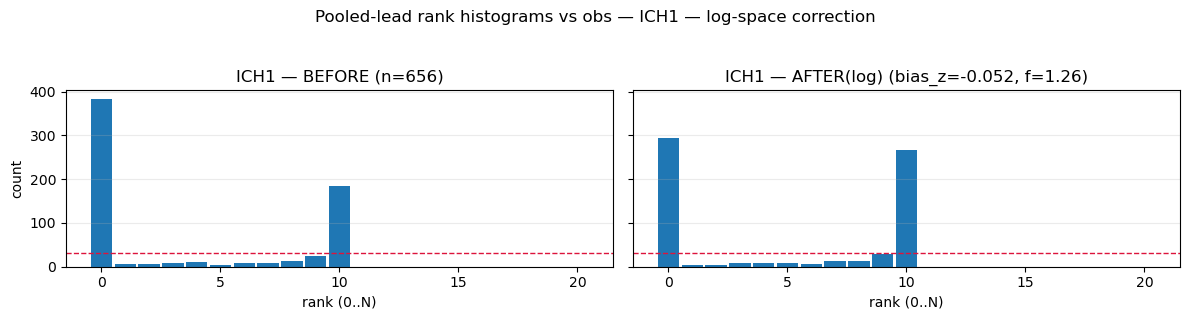

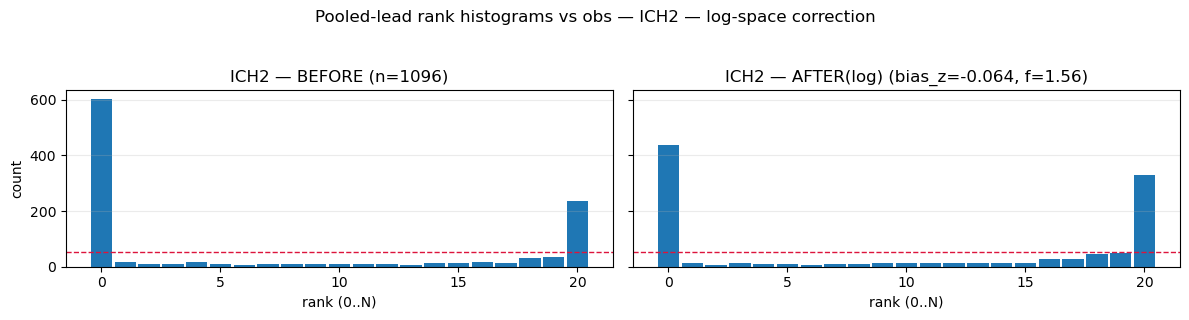

## Rank-hist uniformity diagnostics — log correction (pooled lead times)

,rank0_before_%,rankN_before_%,rank0_after_log_%,rankN_after_log_%,chi2_before,chi2_after_log
model,,,,,,
ICH1,58.5,0.0,45.0,0.0,5186.0,4459.4
ICH2,55.0,21.4,40.0,30.0,7016.9,4818.8


In [7]:
import numpy as np

eps = 1e-3  # small offset to avoid log(0)
f_grid_log = f_grid  # reuse grid

def to_z(q: np.ndarray) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    return np.log(np.maximum(q, 0.0) + eps)

def from_z(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    return np.exp(z) - eps

def apply_bias_inflation_log(ens_q: np.ndarray, bias_z: float, f: float) -> np.ndarray:
    """Apply bias+inflation in log space and return corrected Q members."""
    z = to_z(ens_q)
    mu_z = np.nanmean(z)
    z_corr = (mu_z + bias_z) + f * (z - mu_z)
    return from_z(z_corr)

log_calibration = {}  # model -> dict(bias_z, f, n_cases, crps_before, crps_after)

for model_name in keep_models:
    frame = raw.loc[raw["model"] == model_name, ["valid_time"] + q_cols].copy()
    frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
    frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
    if frame.empty:
        display(Markdown(f"**{model_name}**: no calibration cases after obs alignment"))
        continue

    y = frame["Q_obs"].to_numpy(dtype=float)
    ens = frame[q_cols].to_numpy(dtype=float)

    # bias in z-space based on ensemble-mean in z-space
    ens_mean_z = np.nanmean(to_z(ens), axis=1)
    y_z = to_z(y)
    bias_z = float(np.nanmean(y_z - ens_mean_z))

    crps0 = np.nanmean([crps_ensemble(ens[i], y[i]) for i in range(len(frame))])
    best = (np.inf, None)
    for f in f_grid_log:
        crps_f = np.nanmean([crps_ensemble(apply_bias_inflation_log(ens[i], bias_z, f), y[i]) for i in range(len(frame))])
        if crps_f < best[0]:
            best = (crps_f, float(f))

    crps1, f_best = best
    log_calibration[model_name] = {
        "bias_z": bias_z,
        "f": f_best,
        "n_cases": int(len(frame)),
        "crps_before": float(crps0),
        "crps_after": float(crps1),
    }

log_df = pd.DataFrame(log_calibration).T
display(Markdown("## Fitted log-space correction (one per model, pooled lead times)"))
display(log_df)

# Compare pooled-lead rank histograms: BEFORE vs AFTER(log)
for model_name in keep_models:
    if model_name not in log_calibration:
        continue
    frame = raw.loc[raw["model"] == model_name, ["valid_time"] + q_cols].copy()
    frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
    frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
    if frame.empty:
        continue

    y = frame["Q_obs"].to_numpy(dtype=float)
    ens = frame[q_cols].to_numpy(dtype=float)
    bias_z = log_calibration[model_name]["bias_z"]
    f_best = log_calibration[model_name]["f"]
    ens_corr = np.vstack([apply_bias_inflation_log(ens[i], bias_z, f_best) for i in range(len(frame))])

    r0 = ranks_for_frame(ens, y)
    r1 = ranks_for_frame(ens_corr, y)
    h0 = np.bincount(r0, minlength=N + 1)
    h1 = np.bincount(r1, minlength=N + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    x = np.arange(N + 1)
    axes[0].bar(x, h0, width=0.9)
    axes[0].axhline(len(r0) / (N + 1), color="crimson", ls="--", lw=1.0)
    axes[0].set_title(f"{model_name} — BEFORE (n={len(r0)})")
    axes[0].set_xlabel("rank (0..N)")
    axes[0].set_ylabel("count")
    axes[0].grid(True, axis="y", alpha=0.25)

    axes[1].bar(x, h1, width=0.9)
    axes[1].axhline(len(r1) / (N + 1), color="crimson", ls="--", lw=1.0)
    axes[1].set_title(f"{model_name} — AFTER(log) (bias_z={bias_z:.3f}, f={f_best:.2f})")
    axes[1].set_xlabel("rank (0..N)")
    axes[1].grid(True, axis="y", alpha=0.25)

    fig.suptitle(f"Pooled-lead rank histograms vs obs — {model_name} — log-space correction", y=1.05)
    plt.tight_layout()
    plt.show()

# Uniformity diagnostics for log correction (pooled)
log_uniform = []
for model_name in keep_models:
    if model_name not in log_calibration:
        continue
    frame = raw.loc[raw["model"] == model_name, ["valid_time"] + q_cols].copy()
    frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
    frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
    if frame.empty:
        continue

    y = frame["Q_obs"].to_numpy(dtype=float)
    ens = frame[q_cols].to_numpy(dtype=float)
    bias_z = log_calibration[model_name]["bias_z"]
    f_best = log_calibration[model_name]["f"]
    ens_corr = np.vstack([apply_bias_inflation_log(ens[i], bias_z, f_best) for i in range(len(frame))])

    r0 = ranks_for_frame(ens, y)
    r1 = ranks_for_frame(ens_corr, y)
    s0 = rank_uniformity_stats(r0, N)
    s1 = rank_uniformity_stats(r1, N)
    log_uniform.append({
        "model": model_name,
        "rank0_before_%": round(s0["rank0_pct"], 1),
        "rankN_before_%": round(s0["rankN_pct"], 1),
        "rank0_after_log_%": round(s1["rank0_pct"], 1),
        "rankN_after_log_%": round(s1["rankN_pct"], 1),
        "chi2_before": round(s0["chi2"], 1),
        "chi2_after_log": round(s1["chi2"], 1),
    })

log_uniform_df = pd.DataFrame(log_uniform).set_index("model")
display(Markdown("## Rank-hist uniformity diagnostics — log correction (pooled lead times)"))
display(log_uniform_df)

# Log-space correction per lead time (per model)
Same idea as the pooled correction, but we fit `(bias_z, f)` **separately for each lead time** (still separately by model).
This is more flexible, but uses fewer cases per fit, so estimates can be noisy (especially where coverage is sparse).

## Per-lead-time log-space fitted correction

,lead_time_h,model,n_cases,bias_z,f,crps_before,crps_after
0,6,ICH1,220,-0.069906,0.80,7.951111,8.418480
1,6,ICH2,220,-0.057716,1.06,8.500770,8.854819
2,12,ICH1,220,-0.022970,1.68,10.047412,9.765218
3,12,ICH2,220,-0.032251,1.54,10.393929,9.979929
4,24,ICH1,216,-0.063750,1.18,12.495642,11.698301
5,24,ICH2,219,-0.087656,1.30,13.358464,12.337086
6,36,ICH2,219,-0.043584,2.00,14.183030,13.491218
7,48,ICH2,218,-0.101353,1.52,15.621423,14.742984


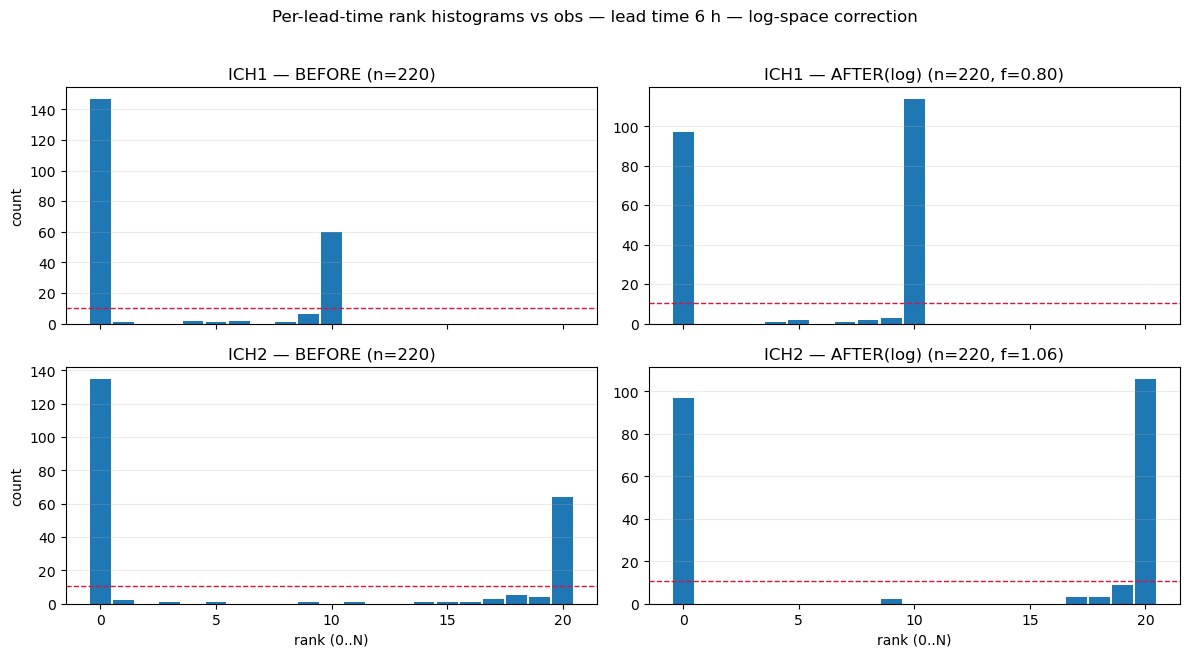

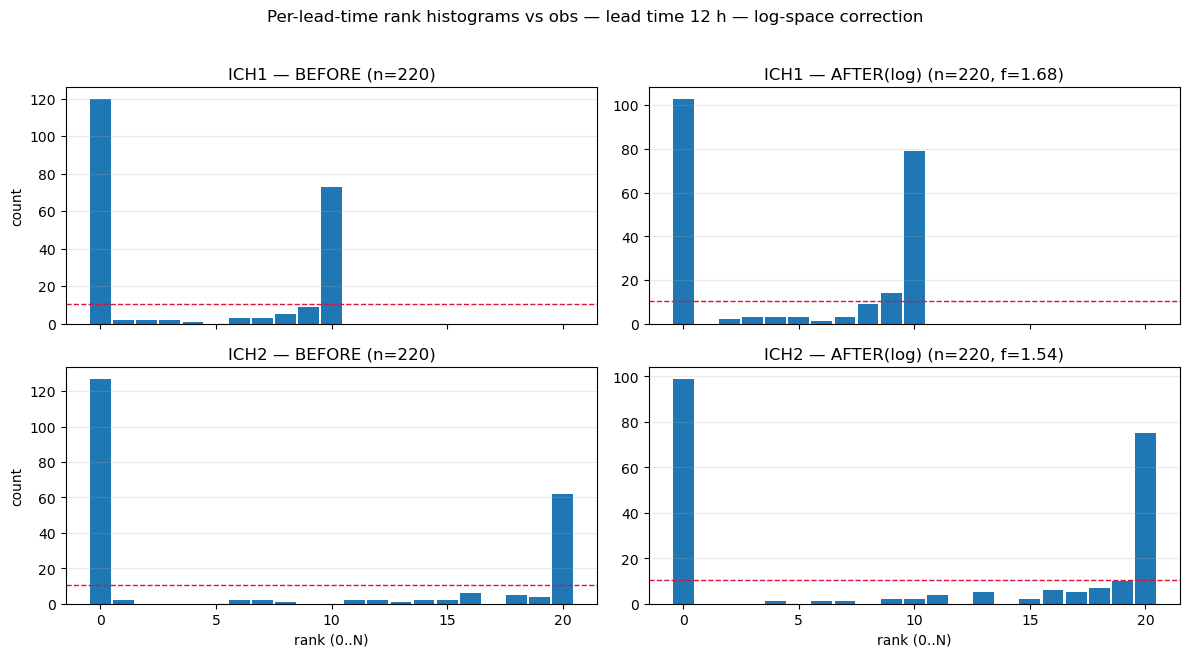

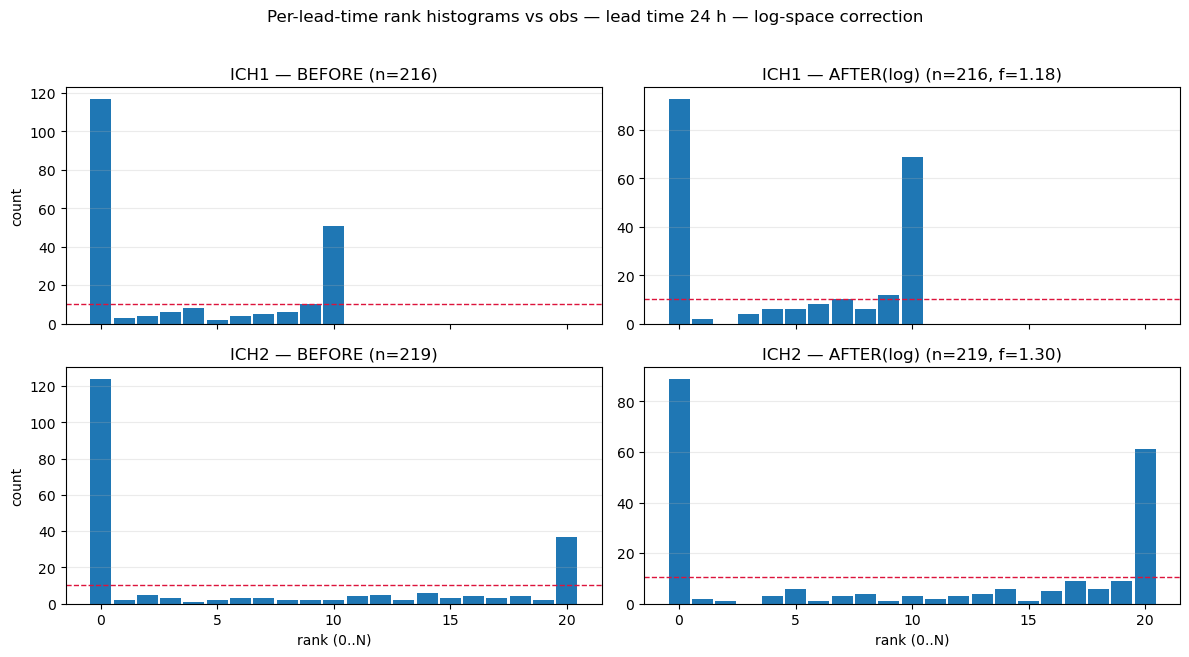

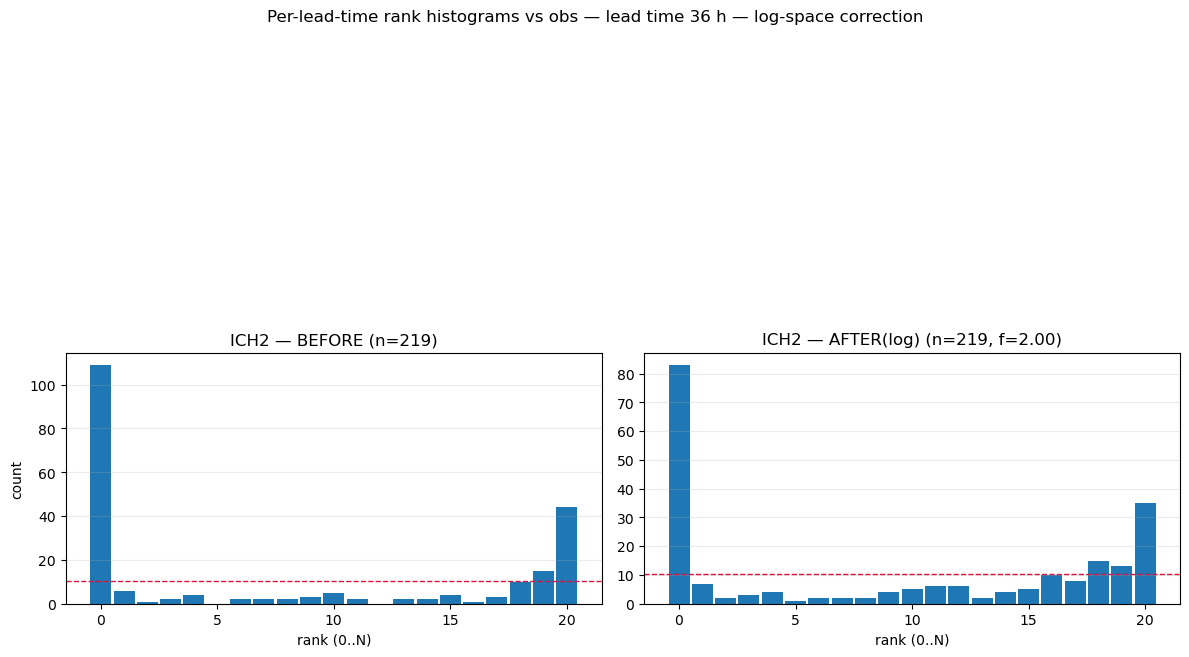

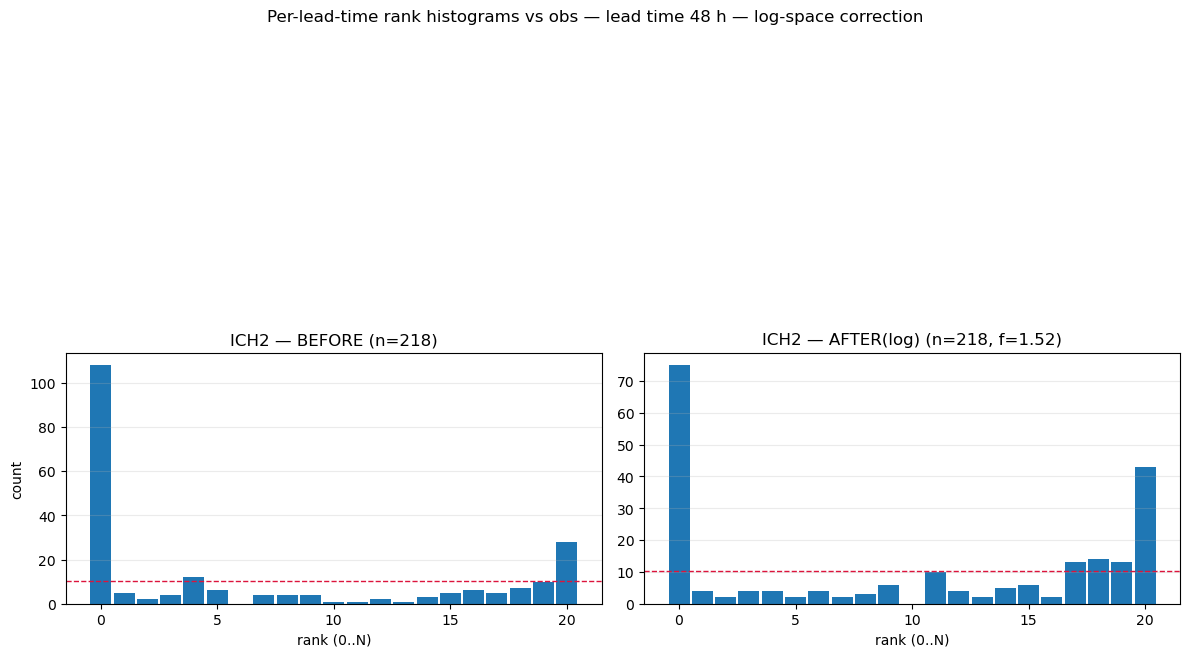

## Rank-hist uniformity diagnostics — per lead time log correction

,lead_time_h,model,n,rank0_before_%,rankN_before_%,rank0_after_log_%,rankN_after_log_%,chi2_before,chi2_after_log
0,6,ICH1,220,66.8,0.0,44.1,0.0,2190.8,1920.5
1,6,ICH2,220,61.4,29.1,44.1,48.2,1916.5,1760.5
2,12,ICH1,220,54.5,0.0,46.8,0.0,1676.3,1418.8
3,12,ICH2,220,57.7,28.2,45.0,34.1,1696.7,1277.9
4,24,ICH1,216,54.2,0.0,43.1,0.0,1397.5,1130.1
5,24,ICH2,219,56.6,16.9,40.6,27.9,1406.6,933.3
6,36,ICH2,219,49.8,20.1,37.9,16.0,1150.6,636.4
7,48,ICH2,218,49.5,12.8,34.4,19.7,1031.6,582.9


In [8]:
import numpy as np
import pandas as pd

# (Re)define helpers here so this cell can run standalone.
eps = 1e-3
f_grid_log = f_grid  # reuse grid from earlier cell

def to_z(q: np.ndarray) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    return np.log(np.maximum(q, 0.0) + eps)

def from_z(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    return np.exp(z) - eps

def apply_bias_inflation_log(ens_q: np.ndarray, bias_z: float, f: float) -> np.ndarray:
    z = to_z(ens_q)
    mu_z = np.nanmean(z)
    z_corr = (mu_z + bias_z) + f * (z - mu_z)
    return from_z(z_corr)

# Fit per (lead_time, model)
rows = []
for lt in lead_times:
    for model_name in keep_models:
        frame = raw.loc[(raw["lead_time_h"] == lt) & (raw["model"] == model_name), ["valid_time"] + q_cols].copy()
        frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
        frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
        if frame.empty:
            continue

        y = frame["Q_obs"].to_numpy(dtype=float)
        ens = frame[q_cols].to_numpy(dtype=float)

        ens_mean_z = np.nanmean(to_z(ens), axis=1)
        bias_z = float(np.nanmean(to_z(y) - ens_mean_z))

        crps0 = float(np.nanmean([crps_ensemble(ens[i], y[i]) for i in range(len(frame))]))

        best = (np.inf, None)
        for f in f_grid_log:
            crps_f = float(np.nanmean([
                crps_ensemble(apply_bias_inflation_log(ens[i], bias_z, f), y[i])
                for i in range(len(frame))
            ]))
            if crps_f < best[0]:
                best = (crps_f, float(f))

        crps1, f_best = best
        rows.append({
            "lead_time_h": int(lt),
            "model": model_name,
            "n_cases": int(len(frame)),
            "bias_z": bias_z,
            "f": f_best,
            "crps_before": crps0,
            "crps_after": crps1,
        })

lt_log_fit = pd.DataFrame(rows)
if lt_log_fit.empty:
    raise ValueError("No obs-aligned cases for per-lead-time log-space fit.")

lt_log_fit = lt_log_fit.sort_values(["lead_time_h", "model"]).reset_index(drop=True)
display(Markdown("## Per-lead-time log-space fitted correction"))
display(lt_log_fit)

# Plots: per lead time, BEFORE vs AFTER(log) for each model
for lt in lead_times:
    lt_i = int(lt)
    sub = lt_log_fit.loc[lt_log_fit["lead_time_h"] == lt_i]
    if sub.empty:
        display(Markdown(f"### Lead time {lt_i} h — no obs-aligned cases"))
        continue

    fig, axes = plt.subplots(len(keep_models), 2, figsize=(12, 3.2 * len(keep_models)), sharex=True, sharey=False)
    if len(keep_models) == 1:
        axes = np.array([axes])
    x = np.arange(N + 1)

    for r, model_name in enumerate(keep_models):
        ax0, ax1 = axes[r, 0], axes[r, 1]
        fit_row = sub.loc[sub["model"] == model_name]
        if fit_row.empty:
            ax0.axis("off")
            ax1.axis("off")
            continue

        bias_z = float(fit_row["bias_z"].iloc[0])
        f_best = float(fit_row["f"].iloc[0])
        n_cases = int(fit_row["n_cases"].iloc[0])

        frame = raw.loc[(raw["lead_time_h"] == lt) & (raw["model"] == model_name), ["valid_time"] + q_cols].copy()
        frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
        frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
        if frame.empty:
            ax0.axis("off")
            ax1.axis("off")
            continue

        y = frame["Q_obs"].to_numpy(dtype=float)
        ens = frame[q_cols].to_numpy(dtype=float)
        ens_corr = np.vstack([apply_bias_inflation_log(ens[i], bias_z, f_best) for i in range(len(frame))])

        r_before = ranks_for_frame(ens, y)
        r_after = ranks_for_frame(ens_corr, y)
        h0 = np.bincount(r_before, minlength=N + 1)
        h1 = np.bincount(r_after, minlength=N + 1)

        ax0.bar(x, h0, width=0.9)
        ax0.axhline(len(r_before) / (N + 1), color="crimson", ls="--", lw=1.0)
        ax0.set_title(f"{model_name} — BEFORE (n={len(r_before)})")
        ax0.set_ylabel("count")
        ax0.grid(True, axis="y", alpha=0.25)

        ax1.bar(x, h1, width=0.9)
        ax1.axhline(len(r_after) / (N + 1), color="crimson", ls="--", lw=1.0)
        ax1.set_title(f"{model_name} — AFTER(log) (n={n_cases}, f={f_best:.2f})")
        ax1.grid(True, axis="y", alpha=0.25)

    for ax in axes[-1, :]:
        ax.set_xlabel("rank (0..N)")

    fig.suptitle(f"Per-lead-time rank histograms vs obs — lead time {lt_i} h — log-space correction", y=1.02)
    plt.tight_layout()
    plt.show()

# Uniformity diagnostics per lead time (before vs after)
urows = []
for _, row in lt_log_fit.iterrows():
    lt_i = int(row["lead_time_h"])
    model_name = row["model"]
    bias_z = float(row["bias_z"])
    f_best = float(row["f"])

    frame = raw.loc[(raw["lead_time_h"] == lt_i) & (raw["model"] == model_name), ["valid_time"] + q_cols].copy()
    frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
    frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
    if frame.empty:
        continue

    y = frame["Q_obs"].to_numpy(dtype=float)
    ens = frame[q_cols].to_numpy(dtype=float)
    ens_corr = np.vstack([apply_bias_inflation_log(ens[i], bias_z, f_best) for i in range(len(frame))])

    r0 = ranks_for_frame(ens, y)
    r1 = ranks_for_frame(ens_corr, y)
    s0 = rank_uniformity_stats(r0, N)
    s1 = rank_uniformity_stats(r1, N)
    urows.append({
        "lead_time_h": lt_i,
        "model": model_name,
        "n": int(s0["n"]),
        "rank0_before_%": round(s0["rank0_pct"], 1),
        "rankN_before_%": round(s0["rankN_pct"], 1),
        "rank0_after_log_%": round(s1["rank0_pct"], 1),
        "rankN_after_log_%": round(s1["rankN_pct"], 1),
        "chi2_before": round(s0["chi2"], 1),
        "chi2_after_log": round(s1["chi2"], 1),
    })

u_df = pd.DataFrame(urows).sort_values(["lead_time_h", "model"])
display(Markdown("## Rank-hist uniformity diagnostics — per lead time log correction"))
display(u_df)

# Flow-binned log-space correction per lead time (bins from Q_obs)
We fit the same 2-parameter correction in log space, but **separately for each lead time AND for 3 flow bins** (low/med/high) defined by the observed discharge `Q_obs` during the calibration period.

**Important limitation**: because bins are defined using `Q_obs`, this is mainly a *diagnostic/calibration* tool (it cannot be applied when observations are not available). If you want an operational version, we can bin by ensemble median instead.

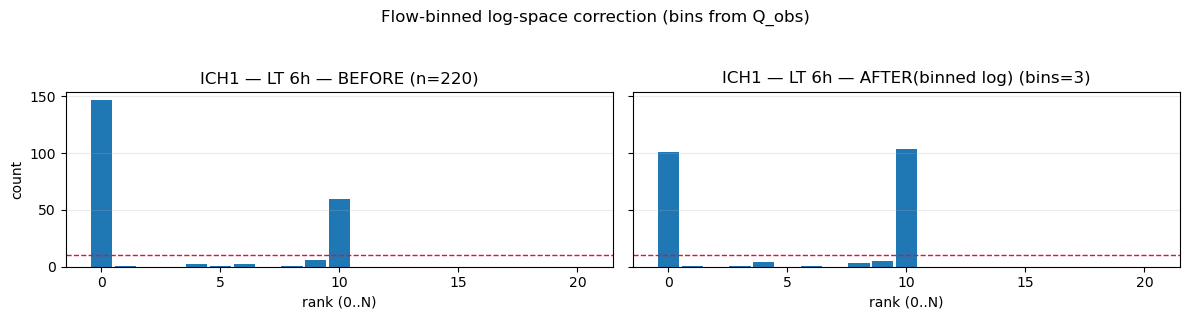

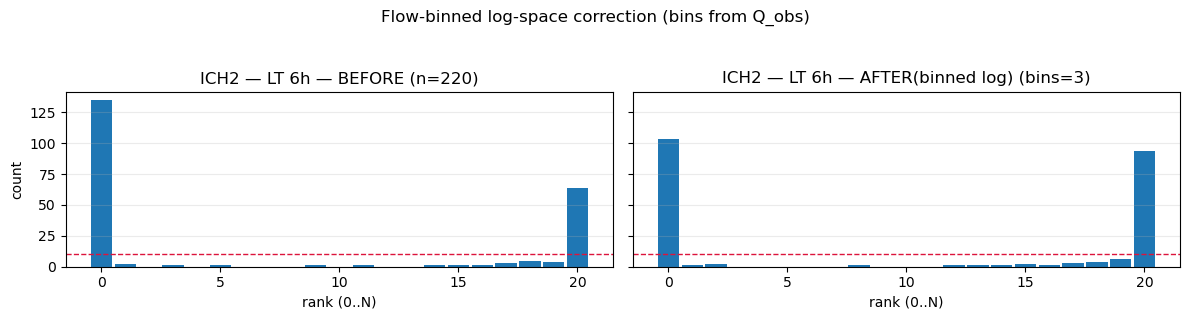

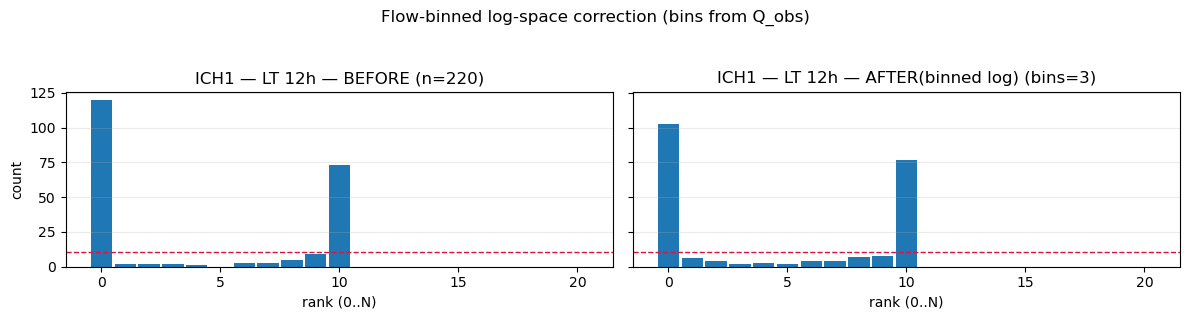

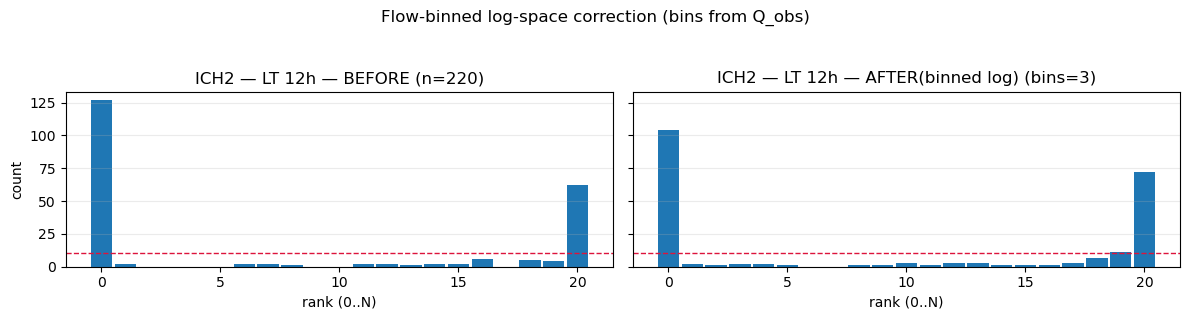

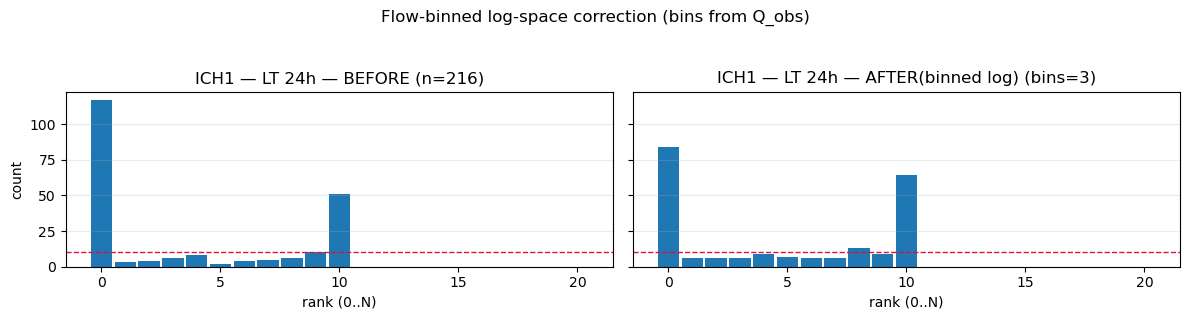

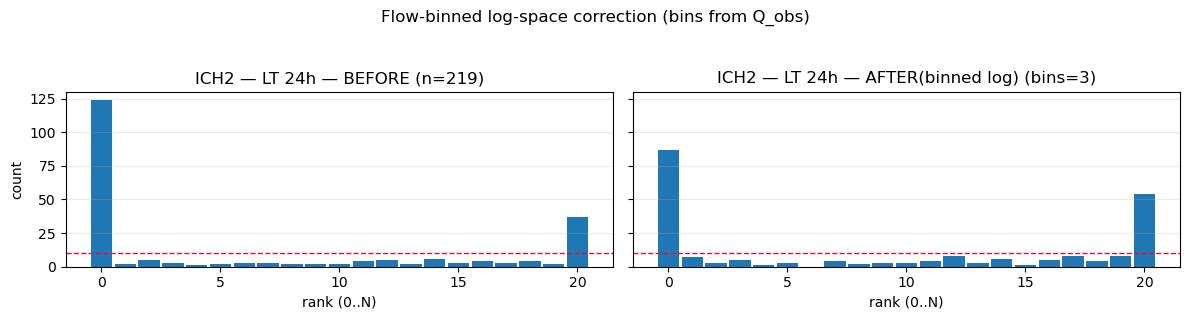

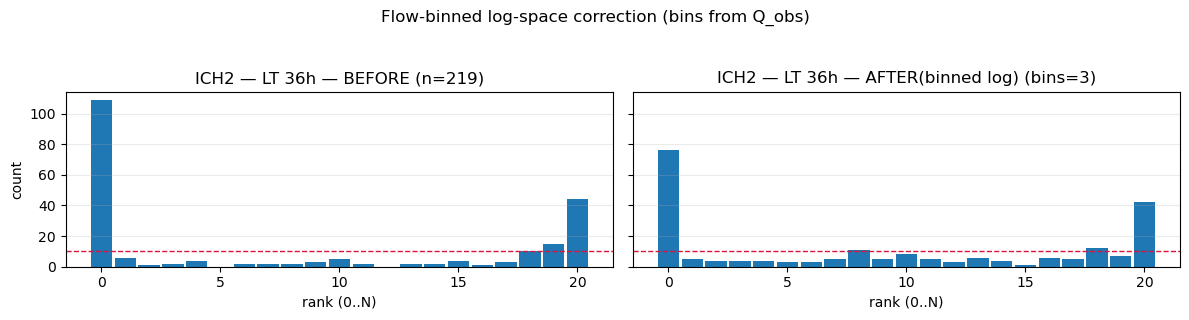

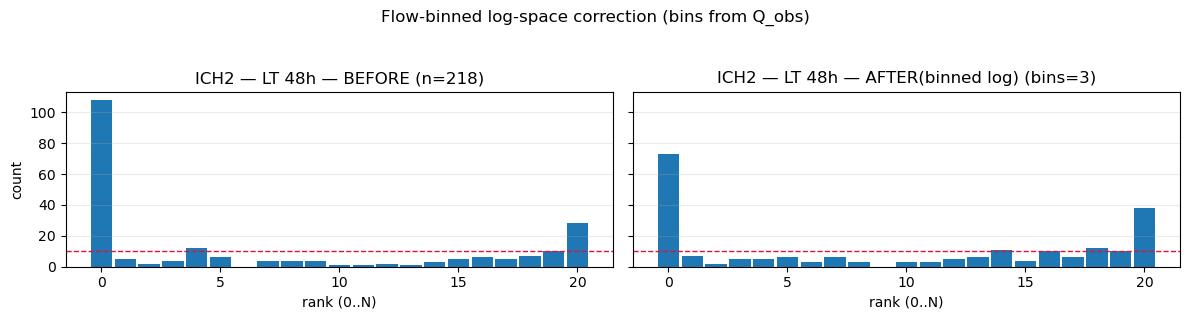

## Fitted parameters — flow-binned log-space correction (per lead time)

,lead_time_h,model,bin,qobs_left,qobs_right,n_cases,bias_z,f,fallback_to_all
0,6,ICH1,0,9.408000,50.782000,74,-0.200619,2.500,False
1,6,ICH1,1,50.782000,103.796000,73,-0.025753,1.675,False
2,6,ICH1,2,103.796000,399.503000,73,0.018446,1.200,False
3,6,ICH2,0,10.221000,51.655000,74,-0.186292,2.500,False
4,6,ICH2,1,51.655000,103.029000,73,-0.010702,0.925,False
5,6,ICH2,2,103.029000,413.758000,73,0.025606,1.475,False
6,12,ICH1,0,14.237000,47.553000,74,-0.067961,2.500,False
7,12,ICH1,1,47.553000,99.153000,73,-0.049525,2.175,False
8,12,ICH1,2,99.153000,392.279000,73,0.049192,1.425,False
9,12,ICH2,0,15.793000,46.503000,74,-0.095292,2.500,False


## Summary — flow-binned log-space correction (per lead time)

,lead_time_h,model,n,crps_before,crps_after,rank0_before_%,rankN_before_%,rank0_after_%,rankN_after_%,chi2_before,chi2_after,n_bins_effective
0,6,ICH1,220,7.951111,7.393950,66.8,0.0,45.9,0.0,2190.8,1791.2,3
1,6,ICH2,220,8.500770,8.036988,61.4,29.1,46.8,42.7,1916.5,1643.3,3
2,12,ICH1,220,10.047412,9.689526,54.5,0.0,46.8,0.0,1676.3,1379.1,3
3,12,ICH2,220,10.393929,9.721221,57.7,28.2,47.3,32.7,1696.7,1328.8,3
4,24,ICH1,216,12.495642,11.043744,54.2,0.0,38.9,0.0,1397.5,922.7,3
5,24,ICH2,219,13.358464,11.327530,56.6,16.9,39.7,24.7,1406.6,827.3,3
6,36,ICH2,219,14.183030,12.298581,49.8,20.1,34.7,19.2,1150.6,568.0,3
7,48,ICH2,218,15.621423,12.789722,49.5,12.8,33.5,17.4,1031.6,510.4,3


In [9]:
import numpy as np
import pandas as pd

# Wider grid: earlier results suggested some lead times want f < 0.8 (deflation).
f_grid_binned = np.linspace(0.2, 2.5, 93)
n_bins_target = 3
min_cases_per_bin = 30

eps = 1e-3
def to_z(q: np.ndarray) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    return np.log(np.maximum(q, 0.0) + eps)

def from_z(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    return np.exp(z) - eps

def apply_bias_inflation_log(ens_q: np.ndarray, bias_z: float, f: float) -> np.ndarray:
    z = to_z(ens_q)
    mu_z = np.nanmean(z)
    z_corr = (mu_z + bias_z) + f * (z - mu_z)
    return from_z(z_corr)

def _safe_quantile_edges(values: np.ndarray, n_bins: int) -> np.ndarray:
    """Return strictly increasing edges for quantile bins; may return fewer bins if ties dominate."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return np.array([0.0, 1.0])
    qs = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(values, qs)
    edges = np.unique(edges)
    # Ensure at least 2 edges
    if edges.size < 2:
        v = float(np.nanmean(values))
        return np.array([v, v + 1e-6])
    return edges

def _assign_bin(x: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Assign each x to a bin index 0..(len(edges)-2) inclusive."""
    # digitize against internal edges (excluding min/max)
    internal = edges[1:-1]
    return np.digitize(x, internal, right=True)

# Fit parameters per (lt, model, bin_idx)
fit_rows = []
summary_rows = []

for lt in lead_times:
    lt_i = int(lt)
    for model_name in keep_models:
        frame = raw.loc[(raw["lead_time_h"] == lt) & (raw["model"] == model_name), ["valid_time"] + q_cols].copy()
        frame = frame.loc[frame["valid_time"].between(cal_start, cal_end)]
        frame = frame.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
        if frame.empty:
            continue

        y = frame["Q_obs"].to_numpy(dtype=float)
        ens = frame[q_cols].to_numpy(dtype=float)

        # Baseline (no correction)
        crps_before = float(np.nanmean([crps_ensemble(ens[i], y[i]) for i in range(len(frame))]))
        r_before = ranks_for_frame(ens, y)
        s_before = rank_uniformity_stats(r_before, N)

        # Define bins from Q_obs quantiles for this (lt, model) subset
        edges = _safe_quantile_edges(y, n_bins_target)
        n_bins = int(max(1, edges.size - 1))
        bin_idx = _assign_bin(y, edges)

        # Fit a fallback (lt, model) correction (no bins) in case bins are too small
        ens_mean_z_all = np.nanmean(to_z(ens), axis=1)
        bias_z_all = float(np.nanmean(to_z(y) - ens_mean_z_all))
        best_all = (np.inf, None)
        for f in f_grid_binned:
            crps_f = float(np.nanmean([
                crps_ensemble(apply_bias_inflation_log(ens[i], bias_z_all, f), y[i])
                for i in range(len(frame))
            ]))
            if crps_f < best_all[0]:
                best_all = (crps_f, float(f))
        _, f_all = best_all

        # Fit per bin
        params_by_bin = {}
        for b in range(n_bins):
            mask = bin_idx == b
            n_b = int(np.sum(mask))
            if n_b == 0:
                continue

            # If too few cases, fall back to the (lt, model) fit
            if n_b < min_cases_per_bin:
                params_by_bin[b] = {"bias_z": bias_z_all, "f": f_all, "fallback": True, "n": n_b}
                continue

            y_b = y[mask]
            ens_b = ens[mask]
            ens_mean_z = np.nanmean(to_z(ens_b), axis=1)
            bias_z = float(np.nanmean(to_z(y_b) - ens_mean_z))
            best = (np.inf, None)
            for f in f_grid_binned:
                crps_f = float(np.nanmean([
                    crps_ensemble(apply_bias_inflation_log(ens_b[i], bias_z, f), y_b[i])
                    for i in range(len(y_b))
                ]))
                if crps_f < best[0]:
                    best = (crps_f, float(f))
            _, f_best = best
            params_by_bin[b] = {"bias_z": bias_z, "f": f_best, "fallback": False, "n": n_b}

        # Record fit table rows
        for b in range(n_bins):
            left = float(edges[b])
            right = float(edges[b + 1])
            p = params_by_bin.get(b)
            if p is None:
                continue
            fit_rows.append({
                "lead_time_h": lt_i,
                "model": model_name,
                "bin": b,
                "qobs_left": left,
                "qobs_right": right,
                "n_cases": int(p["n"]),
                "bias_z": float(p["bias_z"]),
                "f": float(p["f"]),
                "fallback_to_all": bool(p["fallback"]),
            })

        # Apply binned correction using each case Q_obs bin
        ens_corr = np.empty_like(ens, dtype=float)
        for i in range(len(frame)):
            b = int(bin_idx[i])
            if b not in params_by_bin:
                # Should be rare; use fallback
                bias_z_i, f_i = bias_z_all, f_all
            else:
                bias_z_i, f_i = params_by_bin[b]["bias_z"], params_by_bin[b]["f"]
            ens_corr[i] = apply_bias_inflation_log(ens[i], bias_z_i, f_i)

        crps_after = float(np.nanmean([crps_ensemble(ens_corr[i], y[i]) for i in range(len(frame))]))
        r_after = ranks_for_frame(ens_corr, y)
        s_after = rank_uniformity_stats(r_after, N)

        summary_rows.append({
            "lead_time_h": lt_i,
            "model": model_name,
            "n": int(len(frame)),
            "crps_before": crps_before,
            "crps_after": crps_after,
            "rank0_before_%": round(s_before["rank0_pct"], 1),
            "rankN_before_%": round(s_before["rankN_pct"], 1),
            "rank0_after_%": round(s_after["rank0_pct"], 1),
            "rankN_after_%": round(s_after["rankN_pct"], 1),
            "chi2_before": round(s_before["chi2"], 1),
            "chi2_after": round(s_after["chi2"], 1),
            "n_bins_effective": n_bins,
        })

        # Plot rank hist BEFORE/AFTER for this lead time (per model), 2 panels
        h0 = np.bincount(r_before, minlength=N + 1)
        h1 = np.bincount(r_after, minlength=N + 1)
        x = np.arange(N + 1)
        fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
        axes[0].bar(x, h0, width=0.9)
        axes[0].axhline(len(r_before) / (N + 1), color="crimson", ls="--", lw=1.0)
        axes[0].set_title(f"{model_name} — LT {lt_i}h — BEFORE (n={len(r_before)})")
        axes[0].set_xlabel("rank (0..N)")
        axes[0].set_ylabel("count")
        axes[0].grid(True, axis="y", alpha=0.25)

        axes[1].bar(x, h1, width=0.9)
        axes[1].axhline(len(r_after) / (N + 1), color="crimson", ls="--", lw=1.0)
        axes[1].set_title(f"{model_name} — LT {lt_i}h — AFTER(binned log) (bins={n_bins})")
        axes[1].set_xlabel("rank (0..N)")
        axes[1].grid(True, axis="y", alpha=0.25)

        fig.suptitle("Flow-binned log-space correction (bins from Q_obs)", y=1.05)
        plt.tight_layout()
        plt.show()

fit_df = pd.DataFrame(fit_rows).sort_values(["lead_time_h", "model", "bin"]).reset_index(drop=True)
summary_df_binned = pd.DataFrame(summary_rows).sort_values(["lead_time_h", "model"]).reset_index(drop=True)

display(Markdown("## Fitted parameters — flow-binned log-space correction (per lead time)"))
display(fit_df)
display(Markdown("## Summary — flow-binned log-space correction (per lead time)"))
display(summary_df_binned)

# Lagged ensemble (pool lead times at same valid time)
A **lagged ensemble** increases ensemble size by concatenating ensemble members from several lead times (i.e., different initialization times) that verify at the same `valid_time`.
This can add spread and sometimes improves rank histograms, but members are not exchangeable (older runs are typically worse / differently biased).
Here we build, per model, a lagged ensemble using a chosen set of lead times and evaluate it vs obs over the obs-available period.

### ICH1: lead-time overlap diagnostics

,n_valid_times
lead_time_h,
1,650


- No lagged ensemble possible from leads [6, 12, 24] (no overlap).

### ICH2: lead-time overlap diagnostics

,n_valid_times
lead_time_h,
1,220
2,433


- Using lagged lead set: **[12, 36]** (n_overlap=217)

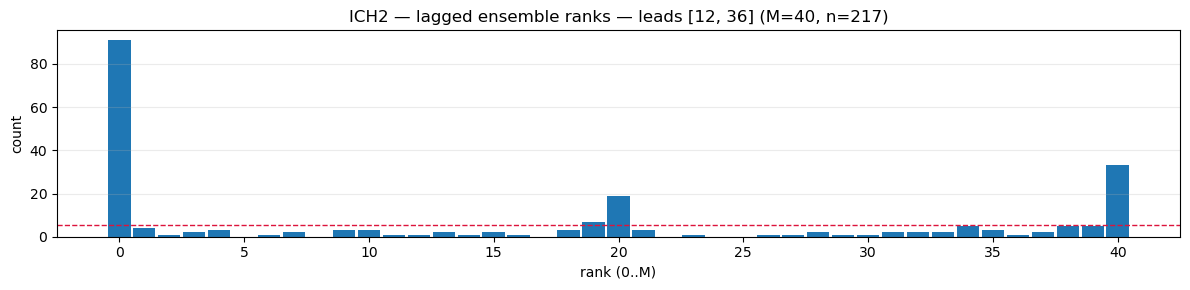

## Lagged ensemble vs single-lead baselines (same timestamps)

,model,product,n,ens_size,crps,rank0_%,rankM_%,chi2
0,ICH2,lagged_12+36,217,40,10.2495,41.9,15.2,1667.3
1,ICH2,lt_12h,219,20,10.3029,58.0,27.9,1694.7
2,ICH2,lt_36h,219,20,14.1830,49.8,20.1,1150.6


In [10]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import chisquare

# Lagged ensemble: concatenate members from multiple lead times verifying at same valid_time.
# We'll auto-pick the lead-time subset (from preferred list) that has the most overlap.
preferred_lagged_leads = [6, 12, 24, 36, 48]
min_leads_required = 2
max_subset_size = None 

rng = np.random.default_rng(42)

def rank_of_obs_var(ens: np.ndarray, obs_value: float) -> int | None:
    ens = np.asarray(ens, dtype=float)
    ens = ens[~np.isnan(ens)]
    if ens.size == 0 or np.isnan(obs_value):
        return None
    less = int(np.sum(ens < obs_value))
    eq = int(np.sum(ens == obs_value))
    if eq > 0:
        return int(less + rng.integers(0, eq + 1))
    return less

def rank_uniformity_stats_var(ranks: np.ndarray, M: int) -> dict:
    ranks = np.asarray(ranks, dtype=int)
    hist = np.bincount(ranks, minlength=M + 1)
    n = int(hist.sum())
    expected = np.full(M + 1, n / (M + 1), dtype=float)
    chi2, p = chisquare(hist, f_exp=expected)
    return {
        "n": n,
        "rank0_pct": 100.0 * hist[0] / n if n else np.nan,
        "rankM_pct": 100.0 * hist[-1] / n if n else np.nan,
        "chi2": float(chi2),
        "p_value": float(p),
    }

def build_lagged_cases(frame: pd.DataFrame, lagged_leads: list[int]) -> tuple[np.ndarray, np.ndarray, pd.DatetimeIndex]:
    """Return (ens_lagged, y, good_times) where all lagged_leads exist; ens_lagged shape [T, N*L]."""
    needed = set(map(int, lagged_leads))
    lead_sets = frame.groupby("valid_time")["lead_time_h"].agg(lambda s: set(map(int, s)))
    good_times = lead_sets.index[lead_sets.apply(lambda s: needed.issubset(s))]
    good_times = pd.DatetimeIndex(sorted(good_times))
    if len(good_times) == 0:
        return np.empty((0, 0)), np.empty((0,)), good_times

    sub = frame.loc[frame["valid_time"].isin(good_times)].copy()
    sub["lead_time_h"] = sub["lead_time_h"].astype(int)
    sub = sub.sort_values(["valid_time", "lead_time_h"])

    ens_list = []
    y_list = []
    for t in good_times:
        rows_t = sub.loc[sub["valid_time"] == t]
        y_t = float(rows_t["Q_obs"].iloc[0])
        parts = []
        for lt in lagged_leads:
            r = rows_t.loc[rows_t["lead_time_h"] == int(lt)]
            if r.empty:
                parts = None
                break
            parts.append(r[q_cols].iloc[0].to_numpy(dtype=float))
        if parts is None:
            continue
        ens_list.append(np.concatenate(parts, axis=0))
        y_list.append(y_t)

    ens_lagged = np.vstack(ens_list) if ens_list else np.empty((0, 0))
    y = np.asarray(y_list, dtype=float)
    return ens_lagged, y, good_times

def pick_best_lead_subset(lead_sets: pd.Series, candidate_leads: list[int]) -> tuple[list[int] | None, int]:
    """Pick subset with max overlap count; tie-break by larger subset size."""
    if not candidate_leads:
        return None, 0
    max_k = len(candidate_leads) if max_subset_size is None else min(max_subset_size, len(candidate_leads))
    best_subset = None
    best = (0, 0)  # (count, k)
    sets_list = list(lead_sets.values)
    for k in range(min_leads_required, max_k + 1):
        for comb in combinations(candidate_leads, k):
            needed = set(comb)
            cnt = sum(1 for s in sets_list if needed.issubset(s))
            if (cnt, k) > best:
                best = (cnt, k)
                best_subset = list(comb)
    return best_subset, best[0]

results = []
plots_done = 0

for model_name in keep_models:
    base = raw.loc[raw["model"] == model_name, ["valid_time", "lead_time_h"] + q_cols].copy()
    base = base.loc[base["valid_time"].between(cal_start, cal_end)]
    base = base.merge(obs_hr.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")
    if base.empty:
        continue

    lead_sets = base.groupby("valid_time")["lead_time_h"].agg(lambda s: set(map(int, s)))
    lead_count = lead_sets.apply(len)
    display(Markdown(f"### {model_name}: lead-time overlap diagnostics"))
    display(lead_count.value_counts().sort_index().rename("n_valid_times").to_frame())

    available = sorted(set(map(int, base["lead_time_h"].dropna().unique())))
    candidate = [lt for lt in preferred_lagged_leads if lt in available]
    subset, n_overlap = pick_best_lead_subset(lead_sets, candidate)
    if subset is None or n_overlap == 0:
        display(Markdown(f"- No lagged ensemble possible from leads {candidate} (no overlap)."))
        continue

    display(Markdown(f"- Using lagged lead set: **{subset}** (n_overlap={n_overlap})"))
    ens_lagged, y, good_times = build_lagged_cases(base, subset)
    if ens_lagged.size == 0:
        display(Markdown(f"- Failed to build lagged cases for {subset} (unexpected)."))
        continue

    M_lag = int(ens_lagged.shape[1])
    crps_lag = float(np.nanmean([crps_ensemble(ens_lagged[i], y[i]) for i in range(len(y))]))
    ranks_lag = np.array([rank_of_obs_var(ens_lagged[i], y[i]) for i in range(len(y))], dtype=object)
    ranks_lag = np.asarray([r for r in ranks_lag if r is not None], dtype=int)
    s_lag = rank_uniformity_stats_var(ranks_lag, M_lag)

    results.append({
        "model": model_name,
        "product": f"lagged_{'+'.join(map(str, subset))}",
        "n": int(len(y)),
        "ens_size": M_lag,
        "crps": round(crps_lag, 4),
        "rank0_%": round(s_lag["rank0_pct"], 1),
        "rankM_%": round(s_lag["rankM_pct"], 1),
        "chi2": round(s_lag["chi2"], 1),
    })

    # Single-lead baselines on the same timestamps
    for lt in subset:
        sub = base.loc[(base["valid_time"].isin(good_times)) & (base["lead_time_h"].astype(int) == int(lt))].copy()
        if sub.empty:
            continue
        y_lt = sub["Q_obs"].to_numpy(dtype=float)
        ens_lt = sub[q_cols].to_numpy(dtype=float)
        crps_lt = float(np.nanmean([crps_ensemble(ens_lt[i], y_lt[i]) for i in range(len(sub))]))
        M = int(ens_lt.shape[1])
        ranks = np.array([rank_of_obs_var(ens_lt[i], y_lt[i]) for i in range(len(sub))], dtype=object)
        ranks = np.asarray([r for r in ranks if r is not None], dtype=int)
        s = rank_uniformity_stats_var(ranks, M)
        results.append({
            "model": model_name,
            "product": f"lt_{int(lt)}h",
            "n": int(len(sub)),
            "ens_size": M,
            "crps": round(crps_lt, 4),
            "rank0_%": round(s["rank0_pct"], 1),
            "rankM_%": round(s["rankM_pct"], 1),
            "chi2": round(s["chi2"], 1),
        })

    # Plot lagged rank histogram (per model)
    if plots_done < 4:
        hist = np.bincount(ranks_lag, minlength=M_lag + 1)
        x = np.arange(M_lag + 1)
        fig, ax = plt.subplots(1, 1, figsize=(12, 3))
        ax.bar(x, hist, width=0.9)
        ax.axhline(len(ranks_lag) / (M_lag + 1), color="crimson", ls="--", lw=1.0)
        ax.set_title(f"{model_name} — lagged ensemble ranks — leads {subset} (M={M_lag}, n={len(ranks_lag)})")
        ax.set_xlabel("rank (0..M)")
        ax.set_ylabel("count")
        ax.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()
        plots_done += 1

res_df = pd.DataFrame(results)
if not res_df.empty:
    res_df = res_df.sort_values(["model", "product"]).reset_index(drop=True)
display(Markdown("## Lagged ensemble vs single-lead baselines (same timestamps)"))
display(res_df)

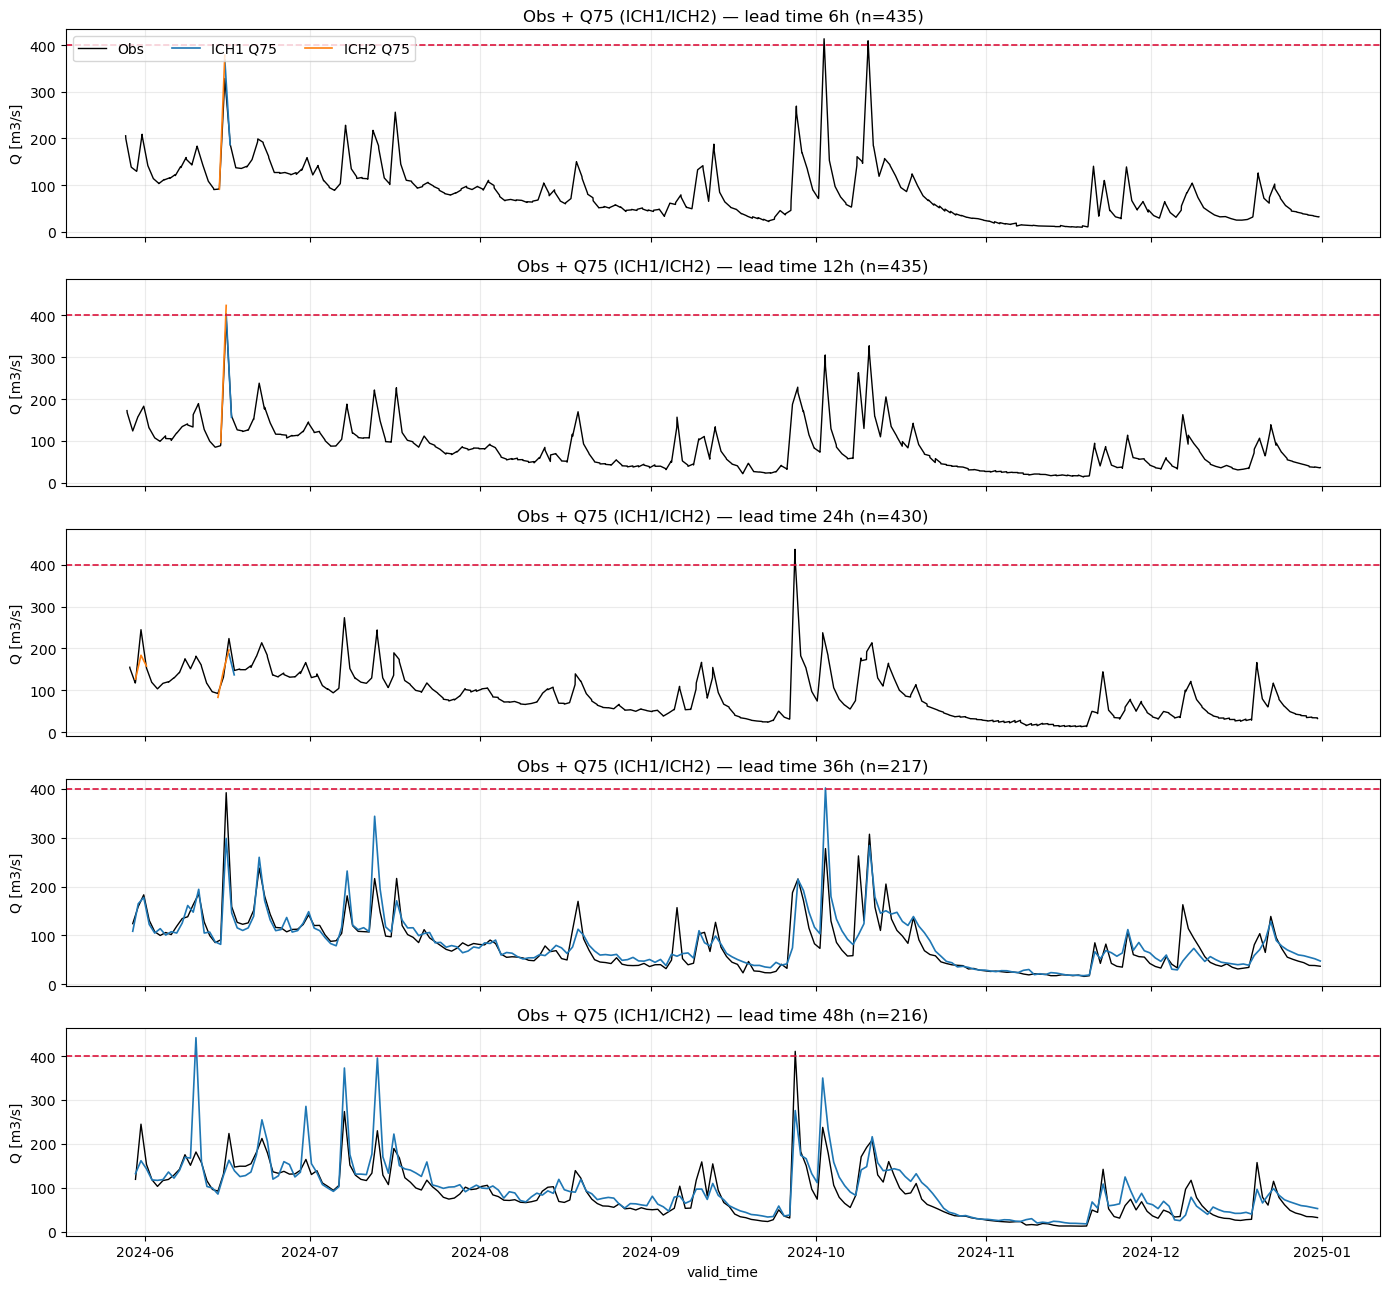

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# extract Q75 time series for ICH1/ICH2
q75 = raw[["valid_time", "model", "lead_time_h", "Q_p75"]].copy()
q75["lead_time_h"] = np.round(q75["lead_time_h"]).astype(int)
q75["Q_p75"] = pd.to_numeric(q75["Q_p75"], errors="coerce")

# plot (all lead times as subplots)
lts_to_plot = [6, 12, 24, 36, 48]  # or sorted(q75["lead_time_h"].unique())
fig, axes = plt.subplots(len(lts_to_plot), 1, figsize=(14, 2.6 * len(lts_to_plot)), sharex=True)

if len(lts_to_plot) == 1:
    axes = [axes]

for ax, LT in zip(axes, lts_to_plot):
    sub = q75[q75["lead_time_h"] == LT].pivot_table(
        index="valid_time", columns="model", values="Q_p75", aggfunc="mean"
    )

    # align to obs timestamps (drops 2025)
    df = sub.join(obs_hr.rename("Q_obs"), how="inner").sort_index()

    ax.plot(df.index, df["Q_obs"], color="black", lw=1.0, label="Obs")
    if "ICH1" in df.columns:
        ax.plot(df.index, df["ICH1"], lw=1.2, label="ICH1 Q75")
    if "ICH2" in df.columns:
        ax.plot(df.index, df["ICH2"], lw=1.2, label="ICH2 Q75")

    ax.axhline(threshold, color="crimson", ls="--", lw=1.2)
    ax.set_title(f"Obs + Q75 (ICH1/ICH2) — lead time {LT}h (n={len(df):,})")
    ax.set_ylabel("Q [m3/s]")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("valid_time")
axes[0].legend(ncols=3, loc="upper left")
plt.tight_layout()
plt.show()

**Models in station2170_ensemble_wide.csv:** C1E, C2E, COSMOE, ICH1, ICH2

**Rank histograms (all models/all lead times):** using overlap window 2020-06-11 12:00:00 → 2024-12-31 23:00:00 (obs hourly points: 39,948)

**Ensemble completeness after obs-alignment (per model):**

,n_rows,min_members,mean_members,pct_full
model,,,,
C2E,9045,20,20.0,100.0
C1E,5364,10,10.0,0.0
ICH2,1096,20,20.0,100.0
ICH1,656,10,10.0,0.0
COSMOE,610,20,20.0,100.0


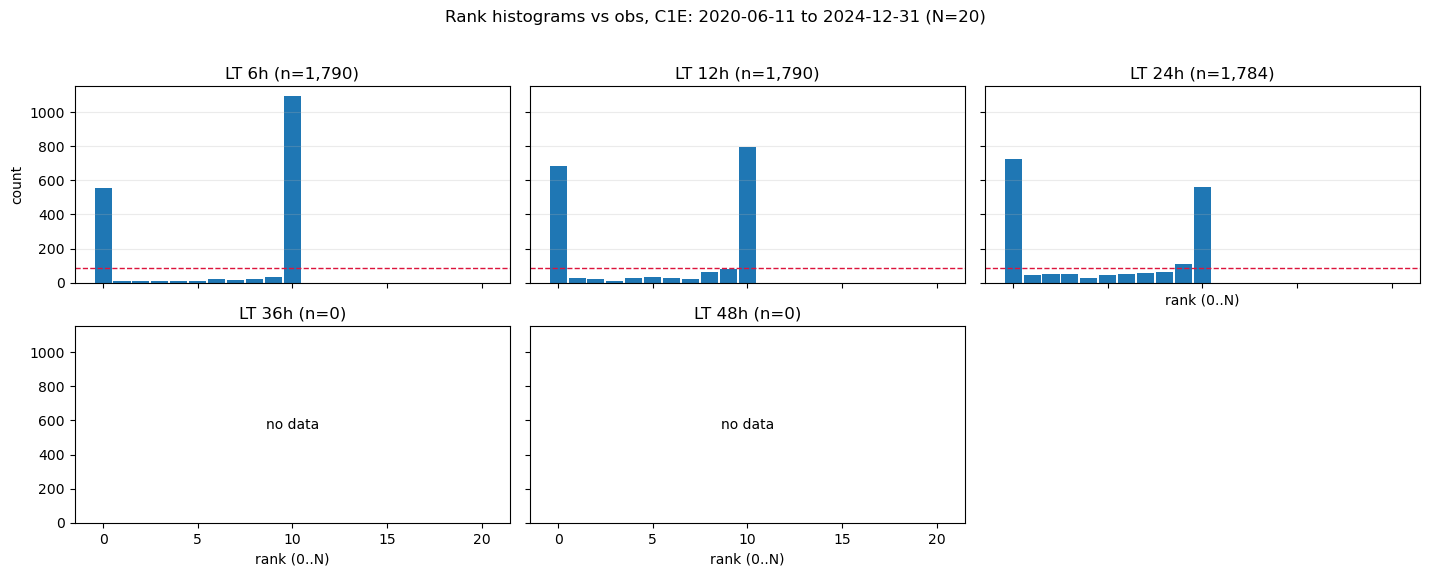

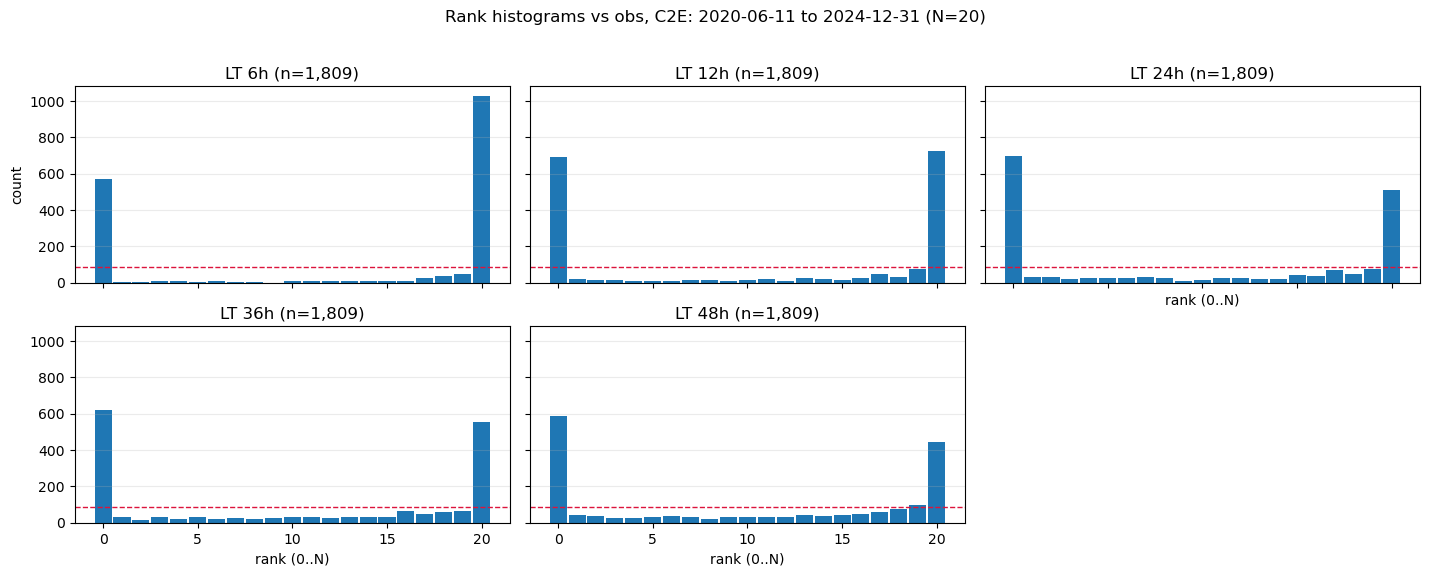

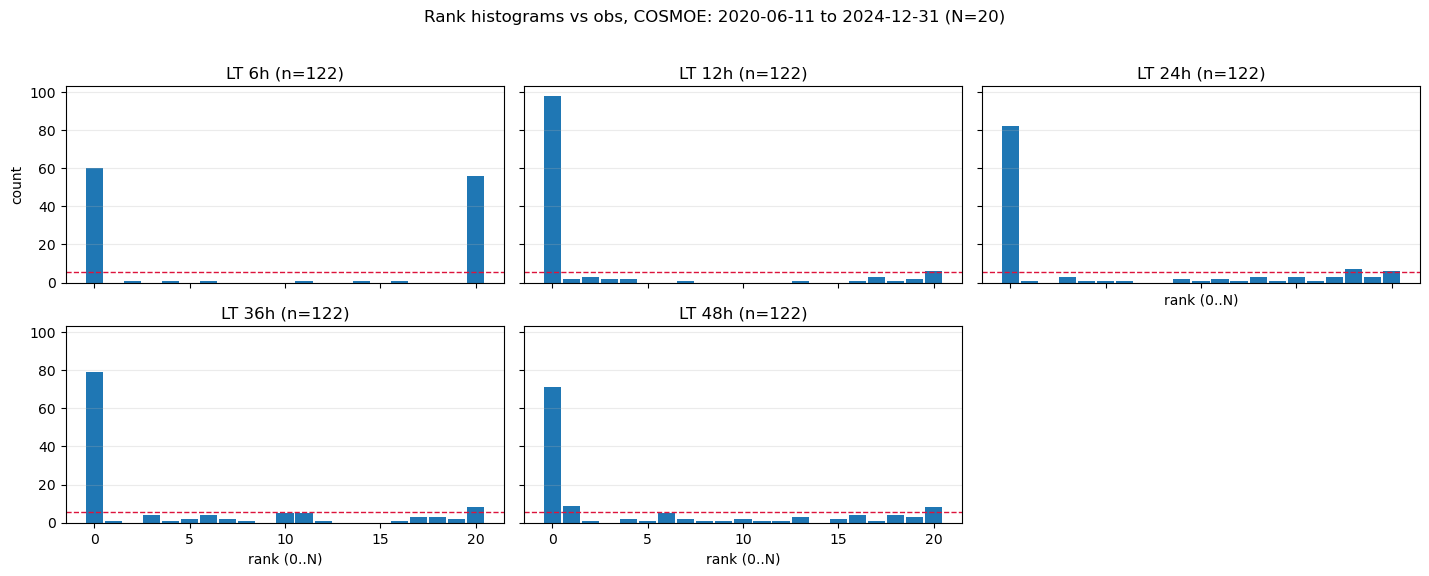

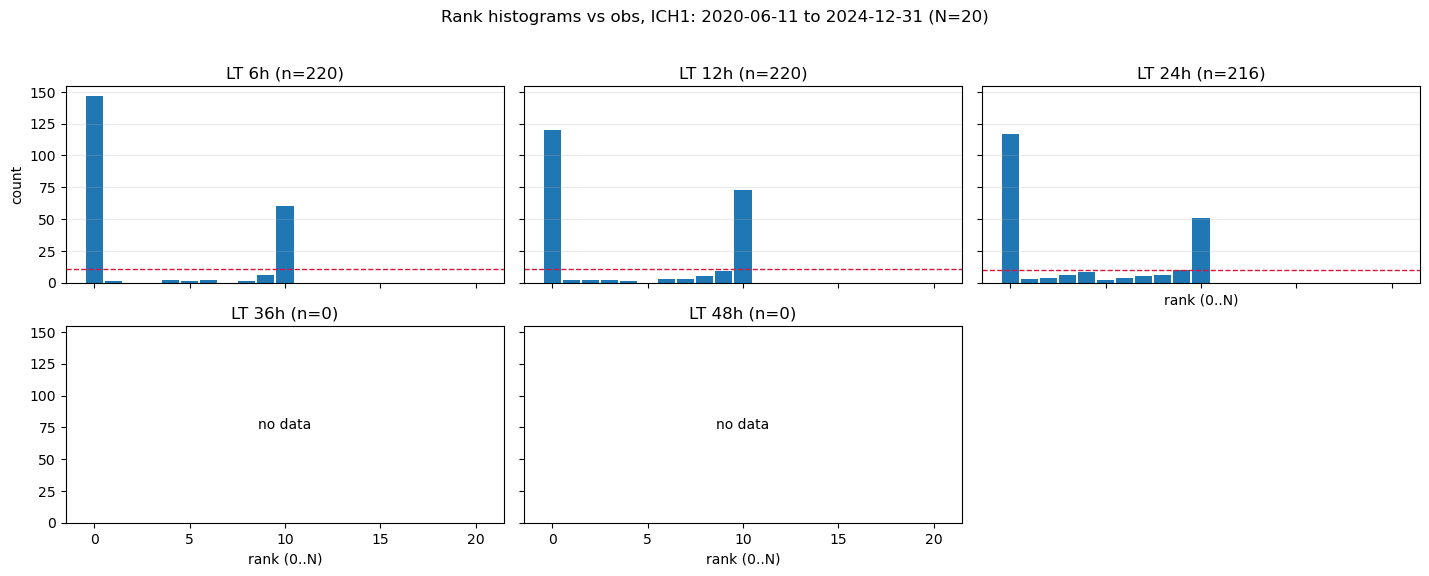

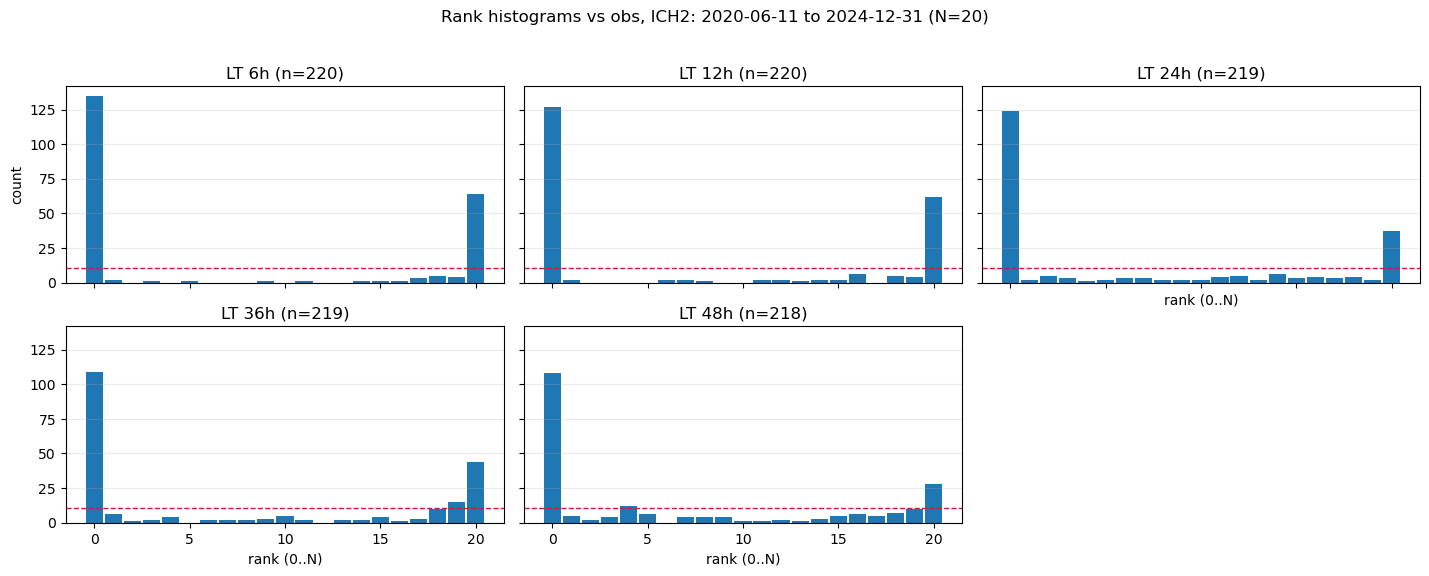

In [12]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Rank histograms for all models
forecast_path = Path("..") / "outputs" / "OFEV_probabilistic" / "station2170_ensemble_wide.csv"

df_fcst = pd.read_csv(forecast_path, parse_dates=["valid_time", "issue_time"])
q_cols = sorted([c for c in df_fcst.columns if c.startswith("Q_e")])
if not q_cols:
    raise ValueError("No ensemble member columns found (expected columns starting with 'Q_e').")

# Normalize types
if "lead_time_h" not in df_fcst.columns:
    raise ValueError("Expected column 'lead_time_h' in station2170_ensemble_wide.csv")

df_fcst = df_fcst.dropna(subset=["valid_time", "model", "lead_time_h"]).copy()
df_fcst["lead_time_h"] = pd.to_numeric(df_fcst["lead_time_h"], errors="coerce")
df_fcst = df_fcst.dropna(subset=["lead_time_h"]).copy()
df_fcst["lead_time_h"] = df_fcst["lead_time_h"].round().astype(int)

models_in_csv = sorted(df_fcst["model"].dropna().unique())
display(Markdown(f"**Models in station2170_ensemble_wide.csv:** {', '.join(models_in_csv)}"))

# Observations
try:
    _ = obs_path
except NameError:
    DATA_DIR = Path("..") / "data" / "Data Fornisseurs"
    obs_path = DATA_DIR / "ARVE/2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv"

obs_all = pd.read_csv(
    obs_path,
    sep=";",
    encoding="cp1252",
    skiprows=8,
    usecols=["Zeitstempel", "Wert"],
    parse_dates=["Zeitstempel"],
)
obs_all = obs_all.rename(columns={"Zeitstempel": "valid_time", "Wert": "Q_obs"})
obs_all["Q_obs"] = pd.to_numeric(obs_all["Q_obs"], errors="coerce")
obs_all = obs_all.dropna(subset=["Q_obs"]).copy()

# Keep only exact hourly timestamps for alignment with forecast valid_time
obs_all = obs_all.loc[
    obs_all["valid_time"].dt.minute.eq(0)
    & obs_all["valid_time"].dt.second.eq(0)
    & obs_all["valid_time"].dt.microsecond.eq(0)
].copy()
obs_hr_all = obs_all.set_index("valid_time")["Q_obs"].sort_index()

# Full overlap window between forecasts and obs
start_full = max(df_fcst["valid_time"].min(), obs_hr_all.index.min())
end_full = min(df_fcst["valid_time"].max(), obs_hr_all.index.max())

display(
    Markdown(
        f"**Rank histograms (all models/all lead times):** using overlap window "
        f"{start_full} → {end_full} (obs hourly points: {len(obs_hr_all.loc[start_full:end_full]):,})"
    )
)

# Restrict to overlap and join obs
N = len(q_cols)
df = df_fcst.loc[df_fcst["valid_time"].between(start_full, end_full)].copy()
df = df.merge(obs_hr_all.rename("Q_obs"), left_on="valid_time", right_index=True, how="inner")

ens_mat = df[q_cols].to_numpy(dtype=float)
y = df["Q_obs"].to_numpy(dtype=float)
n_valid_members = np.sum(~np.isnan(ens_mat), axis=1)
valid = (~np.isnan(y)) & (n_valid_members >= 1)
df = df.loc[valid].copy()
df["n_valid_members"] = n_valid_members[valid]

coverage = (
    df.groupby("model")["n_valid_members"]
    .agg(n_rows="size", min_members="min", mean_members="mean", pct_full=lambda s: (s == N).mean() * 100)
    .sort_values(["n_rows"], ascending=False)
)
coverage["mean_members"] = coverage["mean_members"].round(2)
coverage["pct_full"] = coverage["pct_full"].round(1)
display(Markdown("**Ensemble completeness after obs-alignment (per model):**"))
display(coverage)

def ranks_from_ensemble_allow_nan(ens_matrix: np.ndarray, y_vec: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Random tie-breaking ranks in {0..N}, ignoring NaN members row-wise."""
    mask = ~np.isnan(ens_matrix)
    less = np.sum((ens_matrix < y_vec[:, None]) & mask, axis=1)
    eq = np.sum((ens_matrix == y_vec[:, None]) & mask, axis=1)
    tie_offset = (rng.random(len(y_vec)) * (eq + 1)).astype(int)
    return less + np.where(eq > 0, tie_offset, 0)

rng = np.random.default_rng(42)
all_models = sorted(df["model"].dropna().unique())
all_lts = sorted(df["lead_time_h"].dropna().unique())

x = np.arange(N + 1)
expected_style = dict(color="crimson", ls="--", lw=1.0)

for model_name in all_models:
    dmodel = df.loc[df["model"] == model_name].copy()
    if dmodel.empty:
        continue

    ncols = 3
    nrows = math.ceil(len(all_lts) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.8 * ncols, 2.8 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, lt in zip(axes, all_lts):
        dlt = dmodel.loc[dmodel["lead_time_h"] == lt]
        if dlt.empty:
            ax.set_title(f"LT {lt}h (n=0)")
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.grid(False)
            continue

        E = dlt[q_cols].to_numpy(dtype=float)
        Y = dlt["Q_obs"].to_numpy(dtype=float)
        ranks = ranks_from_ensemble_allow_nan(E, Y, rng=rng)
        counts = np.bincount(ranks.astype(int), minlength=N + 1)
        n_cases = int(ranks.size)

        ax.bar(x, counts, width=0.9)
        ax.axhline(n_cases / (N + 1), **expected_style)
        ax.set_title(f"LT {lt}h (n={n_cases:,})")
        ax.grid(True, axis="y", alpha=0.25)

    for ax in axes[len(all_lts):]:
        ax.axis("off")

    axes[0].set_ylabel("count")
    for ax in axes[max(0, len(all_lts) - ncols):len(all_lts)]:
        ax.set_xlabel("rank (0..N)")

    fig.suptitle(
        f"Rank histograms vs obs, {model_name}: {start_full.date()} to {end_full.date()} (N={N})",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()